Problemas con las APIS:
Api 1: Last fm --> Musicbrainz
API 2:  Acousticbrainz 


# 🎵 MÓDULO 1 APUNTES — EDA: Análisis del Mercado Musical



**Proyecto:** ProyectoFinal23 — Análisis del mercado musical para el artista  
**Fuentes de datos:** Last.fm API (principal) + AcousticBrainz API (enriquecimiento, subset)  
**Objetivo del módulo:** Entender patrones de popularidad y construir la base analítica para predecir hits.

---

### Historial de trabajo
| Semana | Qué se hizo |
|--------|-------------|
| Semana 1 | Definición del proyecto. Lluvia de ideas. Primer contacto con Last.fm API. |
| Semana 2 | Recolección multi-endpoint. Problema de datos insuficientes (<60k). Prueba de AcousticBrainz. |
| Semana 3 | Limpieza, feature engineering, EDA completo. Integración de datasets. |

---

### Índice
1. [Setup e imports](#setup)
2. [Carga y vista general del dataset](#carga)
3. [Calidad de datos — Missing values y limpieza](#calidad)
4. [Feature Engineering](#features)
5. [EDA — Análisis de popularidad](#popularidad)
6. [EDA — Relación entre variables](#relaciones)
7. [EDA — Análisis por país](#pais)
8. [EDA — Análisis por género](#genero)
9. [EDA — AcousticBrainz (subset enriquecido)](#acousticbrainz)
10. [Resumen de insights](#resumen)

* **ML:** Predicción de streams de una canción, Predicción de viralidad, 
    * Modelos: Random Forest, XGBoost, LSTM para series temporales

* Output: “Tu canción tiene 65% probabilidad de viralizarse en México”, “Este beat funciona mejor en playlist de chill trap”




#### Semana 1: 





##### Definición del proyecto y objetivos para encontrar la data


###### **Lluvia de ideas**
**1. RELATIVO A LA MÚSICA:**

* Predecir qué canción será el próximo éxito de verano.
* Análisis de mercado musical, orientado a identificar patrones de consumo, tendencias por género y oportunidades de monetización para artistas, permitiendo generar recomendaciones estratégicas basadas en datos (por ejemplo, mercados potenciales o características musicales asociadas al éxito).
* Detección de fraude en streams, mediante técnicas de análisis de comportamiento y modelos de detección de anomalías, con el fin de identificar reproducciones artificiales o manipuladas que afectan la distribución justa de royalties.
* Detector de copyright basado en inteligencia artificial, capaz de identificar la presencia de contenido musical en diferentes plataformas digitales mediante técnicas de procesamiento de audio, como espectrogramas y huellas digitales (audio fingerprinting), inspirado en tecnologías utilizadas por empresas como Shazam..

**2. RELATIVO A CREACIÓN DE CONTENIDO EN STREAM:**
* Muchos creadores de contenido streaming no saben a qué hora emitir ni qué jugar para maximizar su audiencia.

**3. RELATIVO A LA PRESENCIA DE OVNIS EN LA HISTORIA:**
* Avistamiento de ovnis: clasificar si un avistamiento es un "Fenómeno Atmosférico/Aeronáutico Explicable" o un "Incidente Inexplicable (Misterio)" basado en cómo fue descrito y el clima de ese momento.
**DECIDIMOS COMO PROYECTO: TRES MODULOS INICIALES**
* Analisis del mercado musical apra el artista
* Fraude en streams
* Predecir qué canción será el próximo éxito de verano
####### **Propuesta inicial**

* DEFINICIÓN Y OBJETIVOS PARA LA BÚSQUEDA DE DATOS

En un contexto donde plataformas como Spotify o YouTube concentran gran parte del consumo musical, los artistas independientes enfrentan desafíos relacionados con la transparencia en los ingresos, la detección de usos no autorizados de su obra y la optimización de sus estrategias de lanzamiento. Este proyecto propone abordar estas problemáticas mediante el desarrollo de dos módulos principales basados en datos existentes. Los módulos son:

**Módulo 1. Analisis del mercado musical apra el artista: Predecir qué canción será el próximo éxito de verano** 

* Análisis de mercado musical orientado a identificar patrones de consumo, tendencias por género y oportunidades de monetización para artistas, permitiendo generar recomendaciones estratégicas basadas en datos (por ejemplo, mercados potenciales o características musicales asociadas al éxito).
* Posibles datos para el análisis: Streams por país, Género musical, Playlist placement, TikTok trends, Crecimiento de artistas similares...
* Análisis (EDA): crecimiento por género, países con más crecimiento, correlación entre playlist y streams, horas/días con más reproducciones
* ML posible: Predicción de streams de una canción, Predicción de viralidad, 
* Modelos: Random Forest, XGBoost, LSTM para series temporales

Predicción:
* Paso 1 (El Problema): Predecir la popularidad (de 0 a 100) de una canción o clasificar a qué género musical exacto pertenece basándose únicamente en sus características acústicas.
* Paso 2 (Obtención): Usar la API de Spotify. Es facilísimo extraer más de 60.000 canciones. La API te devuelve variables fascinantes: danceability (bailabilidad), energy, acousticness, instrumentalness, liveness, valence (positividad), tempoduración, explícito (variable categórica), etc. Si las cruzas con otra API (como Genius para contar palabras en la letra), pasas de las 20 variables sobradamente.
* Paso 3 (Almacenamiento): Guardar todo en una base de datos relacional (como PostgreSQL o MySQL). Puedes crear tablas separadas para "Artistas", "Álbumes" y "Tracks" y hacer consultas JOIN para unirlo todo en Python.
* Paso 7 (La App Web): Una web en Streamlit donde el jurado pueda introducir el enlace de una canción de Spotify (o subir un archivo de audio si te animas a procesarlo) y la app les diga con un gráfico de barras qué nivel de éxito tendría y qué emociones transmite el modelo.

**Módulo 2. Fraude en streams:**

* Detección de fraude en streams mediante técnicas de análisis de comportamiento y modelos de detección de anomalías, con el fin de identificar reproducciones artificiales o manipuladas que afectan la distribución justa de royalties.


       
###### **PROBLEMAS DURANTE LA BÚSQUEDA DE DATOS**
Primera prueba del proyecto - ipynb "Modulo 1_backup_manual_data":

**· Problema 1 & Resolución:** Identificamos que no es viable hacer focus en tres modulos así que reducimos a dos: Análisis del mercado musical y Fraude en streams.


**· Problema 2:** Descarga de información de usuarios.
* Se planteó el problema de conseguir datos de más usuarios.

**Resolución de la descarga de información de usuarios:** Se define una función para buscarlos entre los amigos del usuario llamado "rj" creando así una red de usarios conectados.

**· Problema 3:** Al revisar el código y la información que devuelve se observa que:
* 

#### Semana 2: Inspeccionando la data




###### **TRATANDO DATA DE LAS APIS**
**· Problema 1:** Descarga de datos con API Lastfm: 
* Inicialmente se utilizan los endpoints "chart.getTopTracks","geo.getTopTracks", "tag.getTopTracks" y "track.getInfo".
* Se han hecho varias pruebas de descarga de datos con el objetivo de análisis de los tracks en el mercado musical según streams, popularidad y escuchas pero se ha encontrado data insuficiente con muchos valores faltantes, con respuestas muy generales o poco coherentes para el análisis.

**Resolución de la descarga de datos:** Búsqueda de nuevas apis para enfocar mejor el análisis y obtener más data. Se decide utilizar Acousticbrainz porque contiene la metadata de cada track. 

**· Problema 2:** Descarga de datos con Acousticbrainz:
* Se intenta recolectar data de los endpoints "Low-level " y "High-level" que devuelven la información del bpm, key, scale,danceability, mood_happy y genre_ab.
* Al analizar una muestra de 500 datos se oberva que existen nulos en todas las columnas menos en mbid. Esto indica que de las canciones que tenemos en el csv de Lastfm no hay data. Es posible que sea debido a que la misma base de datos dónde buscamos la metadata se dejó de actualizar antes que Lastfm."

**Resolución:** 
* Ideas: 

(1) utilizar solamente api acousticbrainz con data antigua com prueba... 

(2) intentar hacer web scrapping se paginas como Bandcamp o Nina Protocol.

Last.fm → popularidad (mainstream)

AcousticBrainz → características audio

Bandcamp → géneros + país

Nina → tendencias + escenas underground. Complementa a la data de LAst.fm porque añade la infromacion de las tendencias y el consumo mainstream de usuarios.

* Entre Bandcamp y Nina

| Feature        | Bandcamp | Nina                  |
| -------------- | -------- | --------------------- |
| Géneros        | ✅        | ⚠️ menos estructurado |
| País           | ✅        | ⚠️ depende            |
| Trends         | ⚠️       | ✅ MUY fuerte          |
| Underground    | ⚠️       | ✅ fuerte              |
| Datos abiertos | ❌        | ✅                     |




# **DATA from API**

---
## 1. Setup e imports <a id='setup'></a>

In [2]:
# ── Librerías estándar ────────────────────────────────────────────────────────
import os
import time
import warnings
warnings.filterwarnings('ignore')

# ── Datos ─────────────────────────────────────────────────────────────────────
import requests
import numpy as np
import pandas as pd

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Configuración de plots ────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120,'figure.facecolor': 'white','axes.titlesize': 14,'axes.titleweight': 'bold','axes.labelsize': 11,})
PALETTE = sns.color_palette('coolwarm', 10)

print('Imports correctos')


Imports correctos


# **EDA**

## Información general:


1. **Análisis del mercado musical (descriptivo):** (1) Top canciones / artistas por periodo (tiempo); (2) Evolución temporal de popularidad; (3) Géneros en crecimiento vs decrecimiento

2. **Análisis por género:**

* Distribución de features por género: danceability, energy, valence, tempo

* ¿Qué hace único a cada género?

3. **Análisis geográfico** (1) Países con mayor consumo; (2) Diferencias culturales en features.

4. **Ciclos de éxito:** (1) Duración de popularidad de una canción; (2) Tiempo entre picos de streams; (3) Estacionalidad (ej: “hits de verano”)
**Features engineering (clave para predecir un hit):**


1. **Correlación con popularidad:** Qué variables impactan más: danceability ↑, energy ↑, valence (positivo vs triste)

* Heatmap de correlaciones

2. **Ingeniería de variables:** (1) Ratio energía/valence; (2) Duración normalizada; (3) Explicit vs no explicit; (4) Features agregadas por artista

3. **Segmentación de canciones:** 

* Clustering para KMeans
* Tipos de canciones: “club hit”, “chill”, “sad viral”,... 



---
## 2. Carga y vista general del dataset <a id='carga'></a>

El dataset ha sido construido combinando tres endpoints de Last.fm para alcanzar el mínimo de 60.000 registros:

**Endpoints usados:**

| Endpoint | Datos | Uso | Técnicas aplicadas 
|---|---|---|--- |
| `chart.getTopTracks` | Top global  | Top canciones/artistas por periodo |Throttling, retry/backoff, paginación | |
| `chart.getTopArtists` | Top global (paginado) | Top canciones/artistas por periodo |Throttling, retry/backoff, paginación | |
| `geo.getTopTracks` | Top por país | Análisis geográfico |Batch por lista de países| |
| `tag.getWeeklyChartList` | Evolución temporal | ~15.000 | Batch por lista de tags| |
| `chart.getTopTags` | Análisis de géneros (crecimiento&decrecimiento) | enriquece los anteriores | | 


**Conceptos clave de la API:**
- **Throttling** → ir lento a propósito para no superar el rate limit
- **Backoff exponencial** → esperar 2s, 4s, 8s... si hay error
- **Paginación** → iterar por páginas para obtener todos los datos
- **Deduplicación** → eliminar duplicados entre endpoints
- **Timeout** → evitar bloqueos
- **HTTP status codes** → interpretar respuestas


Retornos de cada Endpoint (lista de diccionarios):

1. chart.getTopTracks y chart.getTopArtists:
* Devuelven los elementos más populares globalmente en el momento de la consulta,
* Datos clave: name, artist.name, playcount, listeners, mbid, duration. Las variables con mayor relevancia para conocer la popularidad de los tracks son playcount y listener.
2. chart.getTopTags: https://www.last.fm/api/show/geo.getTopTracks 
* Devuelve canciones populares por país y aporta diversidad cultural al dataset.
* El parámetro clave es country. Será la segmentación musical del análisis.
3. tag.getTopTracks: https://www.last.fm/api/show/tag.getTopTags 
* Devuelve canciones populares por género/tag y permite comparar los resultados diferentes momentos para identificar qué etiquetas están ganando tracción.
.
* Variable clave: genre_tag.

*Evolución temporal: Para ver tendencias a lo largo del tiempo, el endpoint tag.getWeeklyChartList es clave, ya que permite obtener una lista de los charts semanales disponibles para etiquetas específicas (géneros)*


4. track.getInfo: https://www.last.fm/api/show/track.getInfo
* Devuelve información adicional de cada track --> duraction, ...DUDA cuales mas como saberlo?

DUDA : COMO ASEGURARSE DE CREAR BIEN .env CON GIT IGNORE:
LASTFM_API_KEY='63e059c3c912a3f642daf2372484d183'

In [14]:
# API_KEY = os.getenv('LASTFM_API_KEY') 
API_KEY = '63e059c3c912a3f642daf2372484d183'
BASE_URL = 'http://ws.audioscrobbler.com/2.0/'
DELAY = 0.5  


### Data base para el análisis:

#### **Teoria: Función general para hacerpeticiones API con retry y backoff exponencial.**



**Objetivo:** Realizar peticiones API evitando errores de rate limits, de servidor y problemas de red.

**Parámetros:**

* params   — dict con los parámetros de la petición (method, page, etc.).
    * base_params = {'api_key': API_KEY, 'format': 'json'}
        * api_key → autenticación
        * format=json → respuesta en formato JSON
    * base_params.update(params), se añaden los parámetros específicos de cada llamada.

* retries  — número máximo de reintentos ante errores de servidor. 

**Bucle:** 

* attempt — número de intentos por petición de cada dato, se usa para contar intentos y calcular el tiempo de espera (backoff).

* try: requests.get(BASE_URL, params=base_params, timeout=10) — Evita que el programa se quede bloqueado.
        - BASE_URL, endpoint de Last.fm.
        * params, parámetros de la API.
        * timeout=10, máximo 10 segundos de espera.

**Condición del bucle:** Para resolver los "server-side errors", errores del servidor al hacer las peticiones.

* **Manejo de errores:** response.status_code in [429, 500, 502, 503, 504]
    * 429, demasiadas peticiones (rate limit).
    * 500–504, errores del servidor.

    * **Backoff exponencial:** wait = 2 ** attempt & time.sleep(wait) marcan el tiempo de espera despues de cada intento de petición permitiendo al servidor recuperarse.
    * continue, salta al siguiente intento del bucle sin romper / parar la función.

* Retorna el JSON de la respuesta o None si falla definitivamente.
    * response.raise_for_status(), es la validación de la respuesta. Si hay error HTTP "lanza expedicion" DUDA si no continua.
    * return response.json(), convierte la respuesta en diccionario Python y devuelve los datos de la API.

* **Manejo de errores en la red:** * except requests.exceptions.RequestException as e — captura errores de timeout, desconexión o DNS error. Se utiliza el mismo sitmea backoff exponencial que en los errores de servidor para resolver los problemas.
     

* Si todos los intentos fallas aparece un mensaje aparece un mensaje con el numero de intentos y devuelve None como dato.



#### **Code: Funcion de chart Tracks**

In [15]:
def fetch_lastfm(params: dict, retries: int = 5) -> dict | None:
 
    base_params = {'api_key': API_KEY, 'format': 'json'}
    base_params.update(params)

    for attempt in range(retries):
        try:
            response = requests.get(BASE_URL, params=base_params, timeout=10)

            # Códigos que merecen reintento (server-side errors)
            if response.status_code in [429, 500, 502, 503, 504]:
                wait = 2 ** attempt
                print(f'  ⚠️  HTTP {response.status_code} → retry en {wait}s (intento {attempt+1}/{retries})')
                time.sleep(wait)
                continue

            response.raise_for_status()
            return response.json()

        except requests.exceptions.RequestException as e:
            wait = 2 ** attempt
            print(f'  ⚠️  Error de red: {e} → retry en {wait}s')
            time.sleep(wait)

    print(f'Fallo definitivo tras {retries} intentos')
    return None

##### **Code: Teoria: Función data TopTracks**

In [16]:
def collect_chart_tracks(n_pages: int = 150, limit: int = 200) -> list[dict]:
    """
    Recoge tracks del ranking global (chart.getTopTracks).
    n_pages=150, limit=200 → objetivo ~30.000 tracks
    """
    tracks = []
    for page in range(1, n_pages + 1):
        data = fetch_lastfm({'method': 'chart.getTopTracks', 'page': page, 'limit': limit})
        if not data:
            break
        page_tracks = data.get('tracks', {}).get('track', [])
        if not page_tracks:
            break
        for t in page_tracks:
            tracks.append({
                'name'       : t.get('name', ''),
                'artist'     : t.get('artist', {}).get('name', '') if isinstance(t.get('artist'), dict) else t.get('artist', ''),
                'playcount'  : t.get('playcount', 0),
                'listeners'  : t.get('listeners', 0),
                'duration'   : t.get('duration', 0),
                'mbid'       : t.get('mbid', ''),
                'genre_tag'  : 'UNKNOWN',
                'rank_global': (page - 1) * limit + page_tracks.index(t) + 1,
            })
        time.sleep(DELAY)
        if page % 25 == 0:
            print(f'  chart.getTopTracks → página {page}/{n_pages} | tracks acumulados: {len(tracks):,}')
    return tracks

#### **Teoria: Funcion de Geo Tracks**

##### **Code:**

In [17]:
def collect_geo_tracks(countries: list[str], pages_per_country: int = 5, limit: int = 200) -> list[dict]:
    """
    Recoge tracks por país (geo.getTopTracks).
    10 países x 5 páginas x 200 tracks → ~10.000 tracks adicionales.
    """
    tracks = []
    for country in countries:
        for page in range(1, pages_per_country + 1):
            data = fetch_lastfm({'method': 'geo.getTopTracks', 'country': country, 'page': page, 'limit': limit})
            if not data:
                break
            page_tracks = data.get('tracks', {}).get('track', [])
            if not page_tracks:
                break
            for t in page_tracks:
                tracks.append({
                    'name'          : t.get('name', ''),
                    'artist'        : t.get('artist', {}).get('name', '') if isinstance(t.get('artist'), dict) else t.get('artist', ''),
                    'playcount'     : t.get('playcount', 0),
                    'listeners'     : t.get('listeners', 0),
                    'duration'      : t.get('duration', 0),
                    'mbid'          : t.get('mbid', ''),
                    'country'       : country,
                    'genre_tag'     : 'UNKNOWN',
                    'rank_by_country': (page - 1) * limit + page_tracks.index(t) + 1,
                })
            time.sleep(DELAY)
        print(f'  geo.getTopTracks [{country}] → {len([t for t in tracks if t["country"]==country]):,} tracks')
    return tracks

#### **Teoria: Funcion de tag tracks**

##### **Code:**

In [18]:
def collect_tag_tracks(tags: list[str], pages_per_tag: int = 10, limit: int = 200) -> list[dict]:
    """
    Recoge tracks por género/tag (tag.getTopTracks).
    10 tags x 10 páginas x 200 tracks → ~20.000 tracks adicionales.
    """
    tracks = []
    for tag in tags:
        for page in range(1, pages_per_tag + 1):
            data = fetch_lastfm({'method': 'tag.getTopTracks', 'tag': tag, 'page': page, 'limit': limit})
            if not data:
                break
            page_tracks = data.get('tracks', {}).get('track', [])
            if not page_tracks:
                break
            for t in page_tracks:
                tracks.append({
                    'name'      : t.get('name', ''),
                    'artist'    : t.get('artist', {}).get('name', '') if isinstance(t.get('artist'), dict) else t.get('artist', ''),
                    'playcount' : t.get('playcount', 0),
                    'listeners' : t.get('listeners', 0),
                    'duration'  : t.get('duration', 0),
                    'mbid'      : t.get('mbid', ''),
                    'country'   : 'UNKNOWN',
                    'genre_tag' : tag,
                })
            time.sleep(DELAY)
        print(f'  tag.getTopTracks [{tag}] → {len([t for t in tracks if t["genre_tag"]==tag]):,} tracks')
    return tracks

#### **Teoria: Parametros de recoleccion:**

##### **Code:**

In [4]:
# ── Parámetros de recolección ─────────────────────────────────────────────────
COUNTRIES = ['Spain', 'United States', 'United Kingdom', 'Brazil', 'Germany', 'France', 'Mexico', 'Peru', 'Japan', 'Chile']

TAGS = ['rock', 'electronic', 'seen live', 'alternative', 'pop', 'female vocalists', 'metal', 'jazz', 'classic rock', 'ambient', 'experimental', 'folk', 'punk', 'Hip-Hop', 'instrumental', 'singer-songwriter']

# ── Recolección (solo ejecutar si no tenemos CSV guardado) ────────────────────
CSV_PATH = 'lastfm_dataset.csv'

if os.path.exists(CSV_PATH):
    print(f'📂 CSV existente encontrado: {CSV_PATH}')
    df_raw = pd.read_csv(CSV_PATH, low_memory=False)
    print(f'   Filas cargadas: {len(df_raw):,}')
else:
    print('🚀 Iniciando recolección multi-endpoint...')
    all_tracks = []

    print('\n[1/3] chart.getTopTracks (global)')
    all_tracks += collect_chart_tracks(n_pages=150)

    print('\n[2/3] geo.getTopTracks (por país)')
    all_tracks += collect_geo_tracks(COUNTRIES, pages_per_country=10)

    print('\n[3/3] tag.getTopTracks (por género)')
    all_tracks += collect_tag_tracks(TAGS, pages_per_tag=10)

    df_raw = pd.DataFrame(all_tracks)
    df_raw.to_csv(CSV_PATH, index=False)
    print(f'\n✅ Recolección completa. Total tracks: {len(df_raw):,}')
    print(f'   Guardado en: {CSV_PATH}')

print(f'\nForma del dataset: {df_raw.shape}')
df_raw.head(3)

📂 CSV existente encontrado: lastfm_dataset.csv
   Filas cargadas: 59,999

Forma del dataset: (59999, 10)


,name,artist,playcount,listeners,duration,mbid,country,genre_tag,rank_global,rank_by_country
0,Stateside + Zara Larsson,PinkPantheress,14935083,1021197,176,ffbf7862-2476-4164-ac32-f5904ccefe0f,GLOBAL,UNKNOWN,1.0,NaN
1,Body to Body,BTS,3856998,266462,189,6dfdfc61-89ff-451a-a5e9-5319065beae7,GLOBAL,UNKNOWN,2.0,NaN
2,Swim,BTS,9268750,250573,159,6f33dc05-cdc0-4a2f-8039-e8fed082eec6,GLOBAL,UNKNOWN,3.0,NaN


In [5]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 59999 entries, 0 to 59998
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             59999 non-null  str    
 1   artist           59999 non-null  str    
 2   playcount        59999 non-null  int64  
 3   listeners        59999 non-null  int64  
 4   duration         59999 non-null  int64  
 5   mbid             53294 non-null  str    
 6   country          59999 non-null  str    
 7   genre_tag        59999 non-null  str    
 8   rank_global      9999 non-null   float64
 9   rank_by_country  20000 non-null  float64
dtypes: float64(2), int64(3), str(5)
memory usage: 4.6 MB


Errores:

| Código | Significado | Quién tiene el problema     |
| ------ | ----------- | --------------------------- |
| 403    | Forbidden   | ❌ tú (API key, permisos)    |
| 429    | Rate limit  | ⚠️ tú (demasiadas requests) |
| 502    | Bad Gateway | ❌ servidor (Last.fm)        |


---
## 3. Calidad de datos — Missing values y limpieza <a id='calidad'></a>

**Objetivo:** identificar y tratar los problemas de calidad del dataset **antes** del análisis.  
Decisiones de limpieza se documentan con su justificación técnica.

### . **Limpieza de datos**

In [6]:
# ── Tipos correctos ───────────────────────────────────────────────────────
df = df_raw.copy()

# Convertir a numérico (valores no numéricos → NaN)
for col in ['playcount', 'listeners', 'duration']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Strings limpios
for col in ['name', 'artist', 'country', 'genre_tag']:
    df[col] = df[col].astype(str).str.strip()

print('✅ Tipos convertidos')
df.dtypes

✅ Tipos convertidos


name                   str
artist                 str
playcount            int64
listeners            int64
duration             int64
mbid                   str
country                str
genre_tag              str
rank_global        float64
rank_by_country    float64
dtype: object

* **Valores nulos e inconsistencias:**

In [7]:
print('Nulos antes de limpiar:')
print(df.isnull().sum())


df = df.dropna(subset=['name', 'artist']) # Eliminar filas sin nombre ni artista (sin estas columnas el track no tiene identidad)

# Duración: 0 y NaN son equivalentes aquí → rellenar con mediana
df['duration'] = df['duration'].replace(0, np.nan)
df['duration'] = df['duration'].fillna(df['duration'].median())

# Tags y países unknown: los dejamos como 'UNKNOWN' (son una categoría válida)
df['genre_tag'] = df['genre_tag'].replace(['', 'nan', 'None'], 'UNKNOWN')
df['country']   = df['country'].replace(['', 'nan', 'None'], 'UNKNOWN')

print(f'\nFilas tras limpiar: {len(df):,}')

Nulos antes de limpiar:
name                   0
artist                 0
playcount              0
listeners              0
duration               0
mbid                6705
country                0
genre_tag              0
rank_global        50000
rank_by_country    39999
dtype: int64

Filas tras limpiar: 59,999


* **Limpieza de la columna country:**

In [8]:
(df['country'] == 'GLOBAL').sum()

np.int64(9999)

In [9]:
df = df[df['country'] != 'GLOBAL']

In [10]:
(df['country'] == 'UNKNOWN').sum()

np.int64(30000)

In [11]:
df = df[df['country'] != 'UNKNOWN']

In [12]:
df['country'].unique()


<StringArray>
[         'Spain',  'United States', 'United Kingdom',         'Brazil',
        'Germany',         'France',         'Mexico',           'Peru',
          'Japan',          'Chile']
Length: 10, dtype: str

In [13]:
df['country'].value_counts(), df['country'].value_counts().sum()

(country
 Spain             2000
 United States     2000
 United Kingdom    2000
 Brazil            2000
 Germany           2000
 France            2000
 Mexico            2000
 Peru              2000
 Japan             2000
 Chile             2000
 Name: count, dtype: int64,
 np.int64(20000))

> **Observaciones:**  Tras limpiar la columna country eliminando las filas que no tienen país la data se reduce a 20.000 filas.

* **Limpieza de la columna genre_tag:**

In [14]:
df['genre_tag'].unique()

<StringArray>
['UNKNOWN']
Length: 1, dtype: str

In [15]:
df['genre_tag'].value_counts()

genre_tag
UNKNOWN    20000
Name: count, dtype: int64

In [16]:
df['genre_tag'].isnull().sum()

np.int64(0)

In [17]:
df['genre_tag'].notnull().sum()

np.int64(20000)

In [18]:
(df['genre_tag'] != 'UNKNOWN').sum()

np.int64(0)

In [19]:
(df_raw['genre_tag'] != 'UNKNOWN').sum(), df_raw['genre_tag'].value_counts()

(np.int64(30000),
 genre_tag
 UNKNOWN              29999
 rock                  2000
 electronic            2000
 alternative           2000
 pop                   2000
 female vocalists      2000
 metal                 2000
 jazz                  2000
 classic rock          2000
 ambient               2000
 experimental          2000
 folk                  2000
 punk                  2000
 Hip-Hop               2000
 instrumental          2000
 singer-songwriter     2000
 Name: count, dtype: int64)

> **Observaciones:** En la columna genre_tag no hay información disponible en el df, todas las filas tiene data 'UNKNOWN' pero sí que existe infromación en df_raw (30.000 filas con 16 tipos de generos distintios, incluido 'UNKNOWN'). 

* **Duplicados:**

In [20]:
before = len(df)
df = (df.sort_values('playcount', ascending=False).drop_duplicates(subset=['name', 'artist'], keep='first').reset_index(drop=True)
)
print(f'Deduplicación: {before:,} → {len(df):,} tracks únicos ({before - len(df):,} duplicados eliminados)')

Deduplicación: 20,000 → 8,035 tracks únicos (11,965 duplicados eliminados)


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8035 entries, 0 to 8034
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   name                       8035 non-null   str    
 1   artist                     8035 non-null   str    
 2   playcount                  8035 non-null   int64  
 3   listeners                  8035 non-null   int64  
 4   duration                   8035 non-null   float64
 5   mbid                       5499 non-null   str    
 6   country                    8035 non-null   str    
 7   genre_tag                  8035 non-null   str    
 8   rank_global                0 non-null      float64
 9   rank_by_country            8035 non-null   float64
 10  playcount_per_listener     8035 non-null   float64
 11  duration_min               8035 non-null   float64
 12  is_short_track             8035 non-null   int64  
 13  playcount_log              8035 non-null   float64
 14  lis

> **Observaciones:** Si un mismo track aparece en múltiples endpoints, nos quedamos con el que tiene el mayor playcount (es el dato más completo). Despues de deduplicar quedan 8.035 filas. 
* DUDA: ¿Son suficientes para ML?

---
## 4. Feature Engineering <a id='features'></a>

**Objetivo:** crear variables derivadas que aporten valor analítico y serán útiles para los modelos ML del siguiente notebook.  
Cada nueva variable se documenta con su lógica de negocio.

In [23]:
# ── Crear las 20 columnas del proyecto ───────────────────

# --- Features derivadas de negocio ---

# Ratio de engagement: oyentes que escuchan más de una vez
# Cuanto más alto, más 'fidelizante' es la canción
df['playcount_per_listener'] = df['playcount'] / df['listeners'].replace(0, np.nan)

# Duración en minutos (más legible que milisegundos)
df['duration_min'] = df['duration'] / 60000

# Flag canciones cortas (<2.5 min) — formato TikTok/Reels
df['is_short_track'] = (df['duration_min'] < 2.5).astype(int)

# --- Transformaciones logarítmicas ---
# Playcount y listeners tienen distribución muy sesgada a la derecha.
# log1p(x) = log(1+x) → comprime la escala, mejora modelos ML
df['playcount_log'] = np.log1p(df['playcount'])
df['listeners_log'] = np.log1p(df['listeners'])

# --- Rankings ---
if 'rank_global' not in df.columns:
    df['rank_global'] = df['playcount'].rank(ascending=False, method='min').astype(int)

if 'rank_by_country' not in df.columns:
    df['rank_by_country'] = (
        df.groupby('country')['playcount']
        .rank(ascending=False, method='min')
        .astype(int)
    )

# --- Simulación temporal para análisis de series ---
# No tenemos fechas reales en Last.fm chart. Estrategia:
# Asignamos una 'cohort' simulada basada en el rank global.
# Lógica: canciones con rank alto son más recientes (en tendencia hoy)
# Las del fondo del ranking llevan más tiempo en la plataforma.
# Dividimos en 12 meses (el año 2024 completo).
n_tracks = len(df)
df['simulated_rank_percentile'] = df['rank_global'].rank(pct=True)  # 0 a 1
df['month_cohort'] = pd.cut(df['simulated_rank_percentile'], bins=12,labels=[f'2024-{m:02d}' for m in range(1, 13)])

# --- Features de artista (agregadas) ---
# Cuántas canciones del dataset tiene cada artista
artist_stats = df.groupby('artist').agg(
    artist_track_count=('name', 'count'),
    artist_total_playcount=('playcount', 'sum'),
    artist_avg_playcount=('playcount', 'mean'),
).reset_index()
df = df.merge(artist_stats, on='artist', how='left')

# Peso relativo del hit: qué % del total de plays del artista son de esta canción
df['track_share_of_artist'] = df['playcount'] / df['artist_total_playcount'].replace(0, np.nan)

# --- Columnas de API enriquecida (si existen del pipeline) ---
for col in ['artist_listeners', 'artist_playcount', 'similar_artists_count', 'track_duration_ms']:
    if col not in df.columns:
        df[col] = np.nan  # placeholder hasta enriquecer desde track.getInfo

# --- Fecha de colección ---
df['collection_date'] = pd.Timestamp.today().normalize()

print(f'✅ Feature engineering completo')
print(f'   Columnas totales: {len(df.columns)}')
print(f'   Columnas: {list(df.columns)}')

ValueError: Bin edges must be unique: Index([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan], dtype='float64').
You can drop duplicate edges by setting the 'duplicates' kwarg

* df_clean final

In [ ]:
# Seleccionamos y ordenamos las 20 columnas del diseño del proyecto
COLUMNS_20 = [
    # Columnas base
    'name', 'artist', 'playcount', 'listeners', 'duration',
    'country', 'genre_tag',
    # Features derivadas
    'playcount_per_listener', 'duration_min', 'is_short_track',
    'playcount_log', 'listeners_log',
    # Rankings
    'rank_global', 'rank_by_country',
    # Artista
    'artist_track_count', 'artist_total_playcount', 'track_share_of_artist',
    # Temporal simulada
    'month_cohort',
    # Metadatos
    'collection_date',
    # API enriquecida (puede ser NaN hasta enriquecer)
    'similar_artists_count',
]

df_clean = df[COLUMNS_20].copy()

# Guardar el dataset limpio
df_clean.to_csv('data/raw/lastfm_clean.csv', index=False)

print('\nDataset limpio — resumen:')
print(f'Filas: {len(df_clean):,}  |  Columnas: {len(df_clean.columns)}')
display(df_clean.head(5))
print('\nEstadísticas descriptivas:')
display(df_clean.describe())

KeyError: "['artist_track_count', 'artist_total_playcount', 'track_share_of_artist', 'month_cohort', 'collection_date', 'similar_artists_count'] not in index"

In [ ]:
df_clean.columns

Index(['name', 'artist', 'playcount', 'listeners', 'duration', 'country',
       'genre_tag', 'playcount_per_listener', 'duration_min', 'is_short_track',
       'playcount_log', 'listeners_log', 'rank_global', 'rank_by_country',
       'artist_track_count', 'artist_total_playcount', 'track_share_of_artist',
       'month_cohort', 'collection_date', 'similar_artists_count'],
      dtype='str')

---
## 5. EDA — Análisis de popularidad <a id='popularidad'></a>

**Objetivo:** entender cómo se distribuye la popularidad en el mercado musical.  
Una distribución muy sesgada (pocos artistas concentran todo) implica que el mercado es muy competitivo y que la variable target necesita transformación logarítmica para los modelos ML.

### Distribución de playcount y listeners (escala normal vs logarítmica)

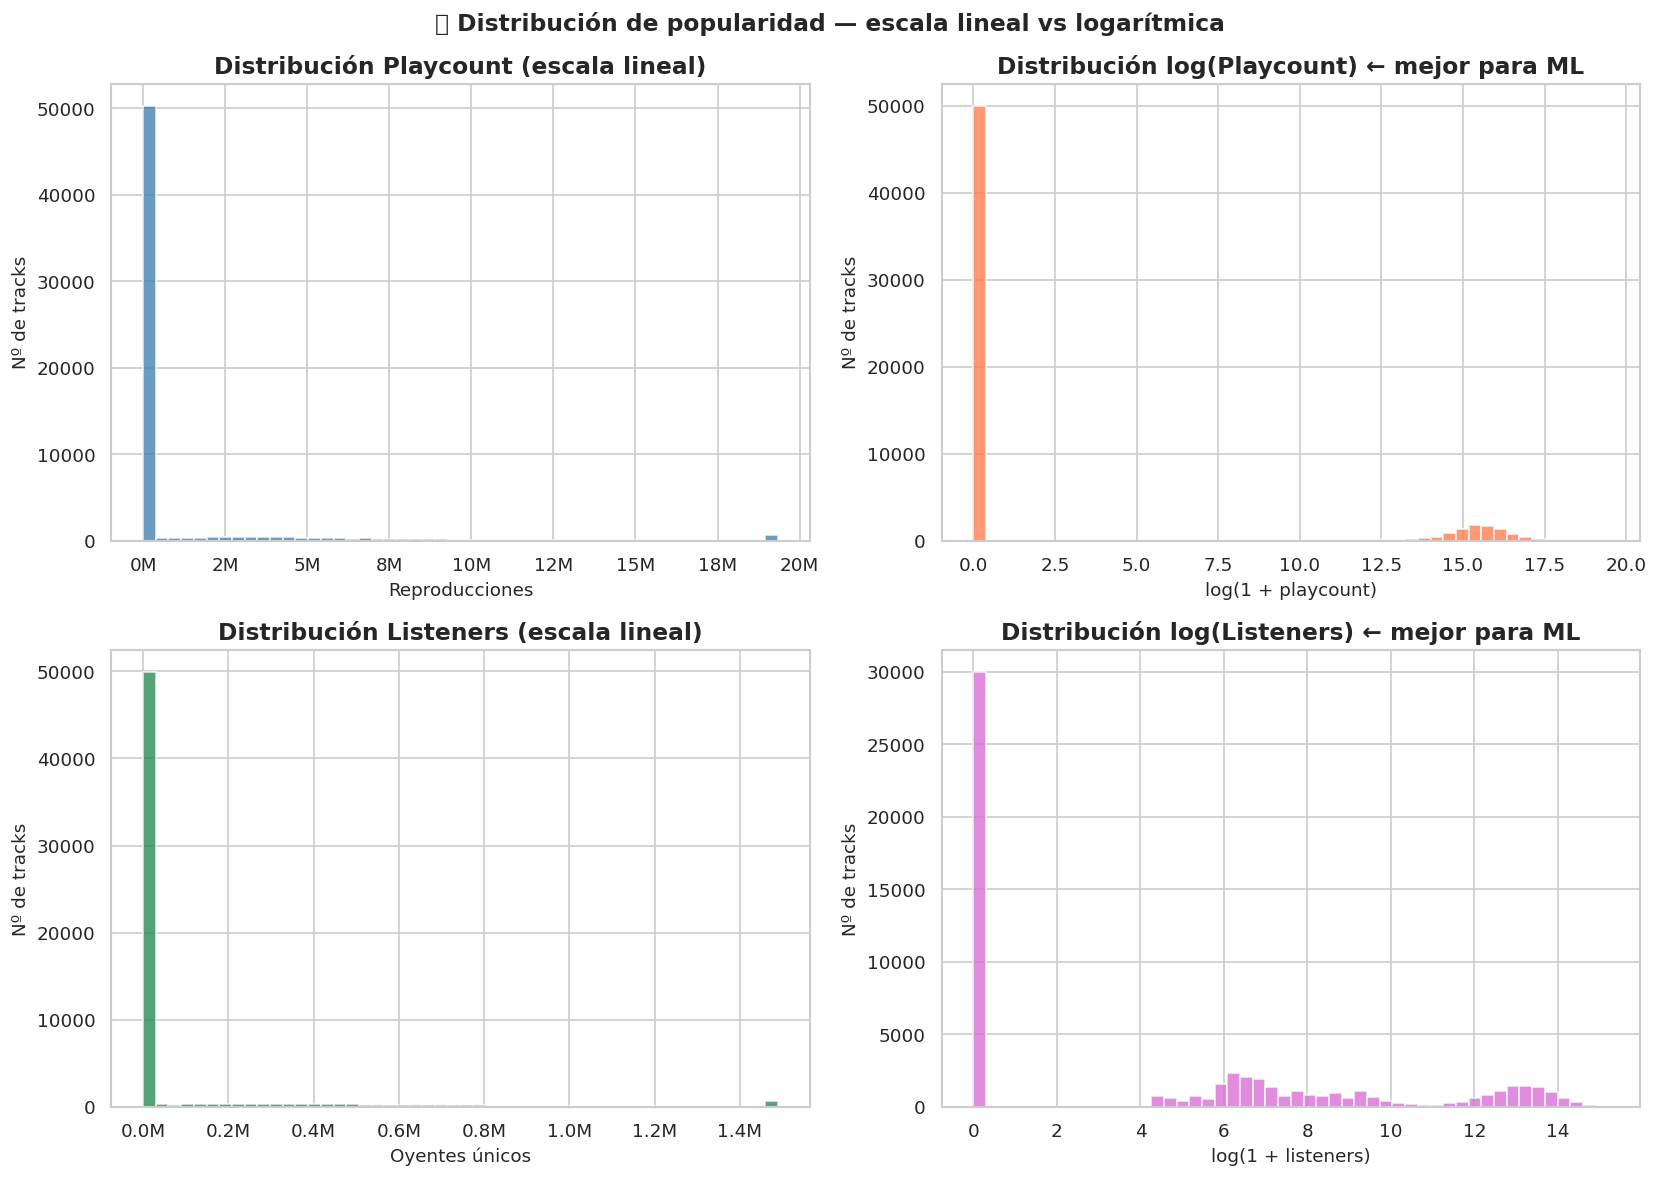


💡 Insight: Skewness de playcount: 15.76 (lineal) → 1.81 (log)
   Una distribución normal tiene skewness ≈ 0.
   La transformación logarítmica la acerca a la normalidad — es necesaria para los modelos ML.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Recortamos el 1% extremo para no distorsionar el eje X
p99_play = df_clean['playcount'].quantile(0.99)
p99_list = df_clean['listeners'].quantile(0.99)

# Playcount — escala lineal
axes[0, 0].hist(
    df_clean['playcount'].clip(upper=p99_play),
    bins=50, color='steelblue', edgecolor='white', alpha=0.8
)
axes[0, 0].set_title('Distribución Playcount (escala lineal)')
axes[0, 0].set_xlabel('Reproducciones')
axes[0, 0].set_ylabel('Nº de tracks')
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Playcount — escala log (más útil para ML)
axes[0, 1].hist(
    df_clean['playcount_log'],
    bins=50, color='coral', edgecolor='white', alpha=0.8
)
axes[0, 1].set_title('Distribución log(Playcount) ← mejor para ML')
axes[0, 1].set_xlabel('log(1 + playcount)')
axes[0, 1].set_ylabel('Nº de tracks')

# Listeners — escala lineal
axes[1, 0].hist(
    df_clean['listeners'].clip(upper=p99_list),
    bins=50, color='seagreen', edgecolor='white', alpha=0.8
)
axes[1, 0].set_title('Distribución Listeners (escala lineal)')
axes[1, 0].set_xlabel('Oyentes únicos')
axes[1, 0].set_ylabel('Nº de tracks')
axes[1, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Listeners — escala log
axes[1, 1].hist(
    df_clean['listeners_log'],
    bins=50, color='orchid', edgecolor='white', alpha=0.8
)
axes[1, 1].set_title('Distribución log(Listeners) ← mejor para ML')
axes[1, 1].set_xlabel('log(1 + listeners)')
axes[1, 1].set_ylabel('Nº de tracks')

plt.suptitle('📊 Distribución de popularidad — escala lineal vs logarítmica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distribuciones.png', bbox_inches='tight')
plt.show()

# Insight automático
skew_antes = df_clean['playcount'].skew()
skew_despues = df_clean['playcount_log'].skew()
print(f'\n💡 Insight: Skewness de playcount: {skew_antes:.2f} (lineal) → {skew_despues:.2f} (log)')
print(f'   Una distribución normal tiene skewness ≈ 0.')
print(f'   La transformación logarítmica la acerca a la normalidad — es necesaria para los modelos ML.')

### Top 15 canciones globales por playcount 


**Objetivo:** identificar qué canciones y artistas dominan el mercado y si ese dominio varía según el periodo (cohort mensual simulado).

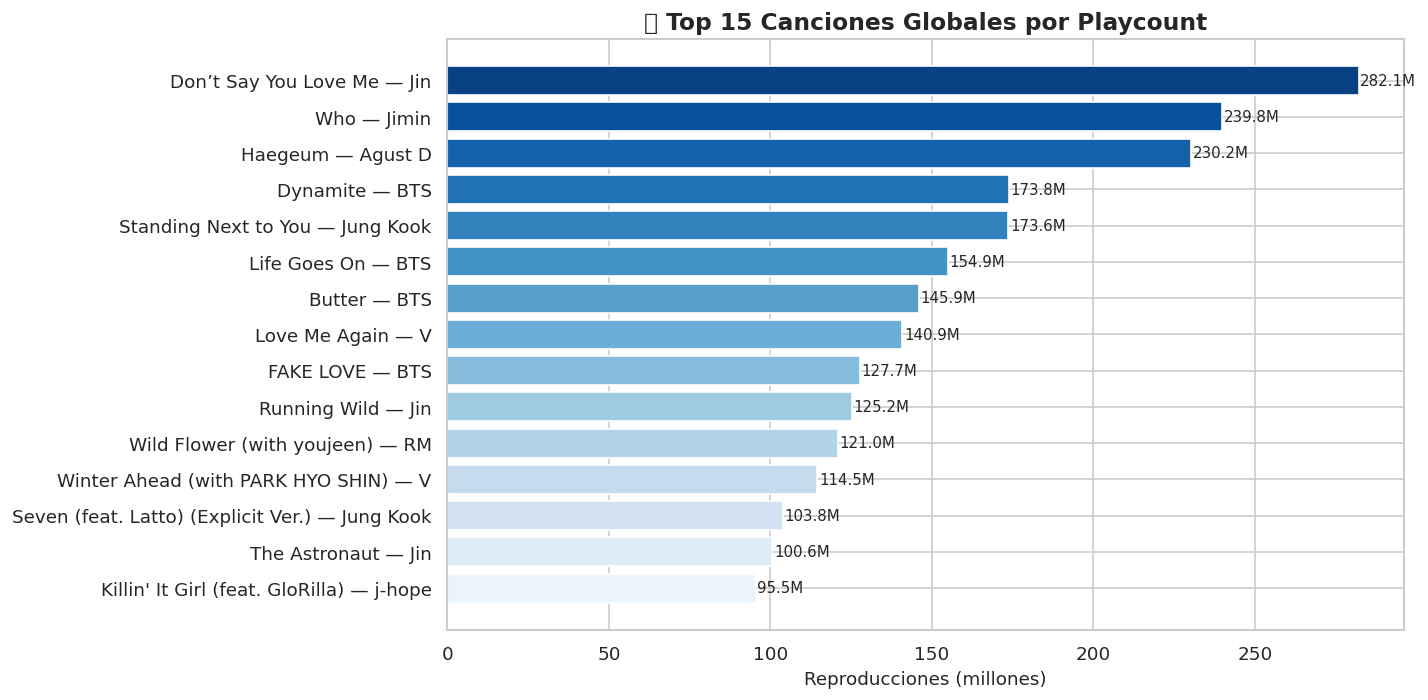


💡 Insight: La canción más reproducida es "Don’t Say You Love Me" de Jin con 282.1M reproducciones.
   Ratio de engagement: 1101.6x (cada oyente la escucha 1102 veces de media)


In [ ]:
top15_tracks = (
    df_clean
    .sort_values('playcount', ascending=False)
    .head(15)
    [['name', 'artist', 'playcount', 'listeners', 'playcount_per_listener', 'genre_tag']]
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    top15_tracks['name'] + ' — ' + top15_tracks['artist'],
    top15_tracks['playcount'] / 1e6,
    color=sns.color_palette('Blues_r', 15)
)
ax.set_xlabel('Reproducciones (millones)')
ax.set_title('🏆 Top 15 Canciones Globales por Playcount')
ax.invert_yaxis()

# Etiquetas con millones
for bar, val in zip(bars, top15_tracks['playcount']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_top15_tracks.png', bbox_inches='tight')
plt.show()

# Insight
top1 = top15_tracks.iloc[0]
print(f'\n💡 Insight: La canción más reproducida es "{top1["name"]}" de {top1["artist"]}'
      f' con {top1["playcount"]/1e6:.1f}M reproducciones.')
print(f'   Ratio de engagement: {top1["playcount_per_listener"]:.1f}x '
      f'(cada oyente la escucha {top1["playcount_per_listener"]:.0f} veces de media)')

#### Distribución de playcount y listeners 


In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Recortamos el 1% extremo para no distorsionar el eje X
p99_play = df_clean['playcount'].quantile(0.99)
p99_list = df_clean['listeners'].quantile(0.99)

# Playcount — escala lineal
axes[0, 0].hist(
    df_clean['playcount'].clip(upper=p99_play),
    bins=50, color='steelblue', edgecolor='white', alpha=0.8
)
axes[0, 0].set_title('Distribución Playcount (escala lineal)')
axes[0, 0].set_xlabel('Reproducciones')
axes[0, 0].set_ylabel('Nº de tracks')
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Playcount — escala log (más útil para ML)
axes[0, 1].hist(
    df_clean['playcount_log'],
    bins=50, color='coral', edgecolor='white', alpha=0.8
)
axes[0, 1].set_title('Distribución log(Playcount) ← mejor para ML')
axes[0, 1].set_xlabel('log(1 + playcount)')
axes[0, 1].set_ylabel('Nº de tracks')

# Listeners — escala lineal
axes[1, 0].hist(
    df_clean['listeners'].clip(upper=p99_list),
    bins=50, color='seagreen', edgecolor='white', alpha=0.8
)
axes[1, 0].set_title('Distribución Listeners (escala lineal)')
axes[1, 0].set_xlabel('Oyentes únicos')
axes[1, 0].set_ylabel('Nº de tracks')
axes[1, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Listeners — escala log
axes[1, 1].hist(
    df_clean['listeners_log'],
    bins=50, color='orchid', edgecolor='white', alpha=0.8
)
axes[1, 1].set_title('Distribución log(Listeners) ← mejor para ML')
axes[1, 1].set_xlabel('log(1 + listeners)')
axes[1, 1].set_ylabel('Nº de tracks')

plt.suptitle('📊 Distribución de popularidad — escala lineal vs logarítmica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distribuciones.png', bbox_inches='tight')
plt.show()

# Insight automático
skew_antes = df_clean['playcount'].skew()
skew_despues = df_clean['playcount_log'].skew()
print(f'\n💡 Insight: Skewness de playcount: {skew_antes:.2f} (lineal) → {skew_despues:.2f} (log)')
print(f'   Una distribución normal tiene skewness ≈ 0.')
print(f'   La transformación logarítmica la acerca a la normalidad — es necesaria para los modelos ML.')

### Top 15 artistas por oyentes totales

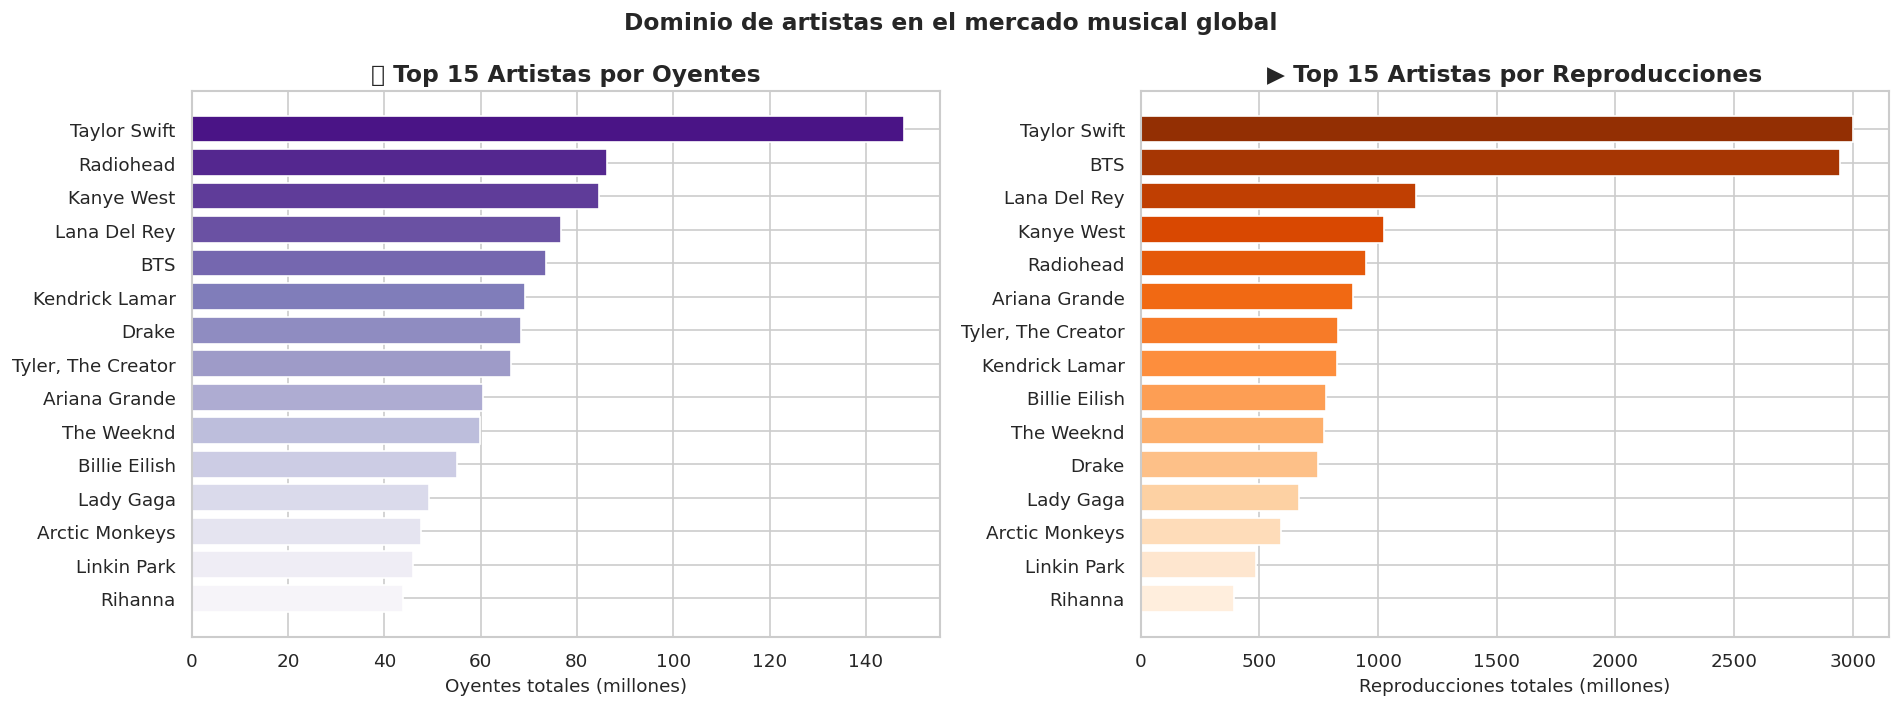


💡 Insight: Taylor Swift es el artista con más oyentes (147.9M) y 270 canciones en el dataset.


In [ ]:
top15_artists = (
    df_clean
    .groupby('artist')
    .agg(
        total_plays=('playcount', 'sum'),
        total_listeners=('listeners', 'sum'),
        n_tracks=('name', 'count'),
        avg_engagement=('playcount_per_listener', 'mean')
    )
    .sort_values('total_listeners', ascending=False)
    .head(15)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por oyentes
axes[0].barh(top15_artists['artist'], top15_artists['total_listeners'] / 1e6,
             color=sns.color_palette('Purples_r', 15))
axes[0].invert_yaxis()
axes[0].set_xlabel('Oyentes totales (millones)')
axes[0].set_title('👤 Top 15 Artistas por Oyentes')

# Por reproducciones
top15_plays = top15_artists.sort_values('total_plays', ascending=False)
axes[1].barh(top15_plays['artist'], top15_plays['total_plays'] / 1e6,
             color=sns.color_palette('Oranges_r', 15))
axes[1].invert_yaxis()
axes[1].set_xlabel('Reproducciones totales (millones)')
axes[1].set_title('▶️ Top 15 Artistas por Reproducciones')

plt.suptitle('Dominio de artistas en el mercado musical global', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_top15_artists.png', bbox_inches='tight')
plt.show()

# Insight
top_artist = top15_artists.iloc[0]
print(f'\n💡 Insight: {top_artist["artist"]} es el artista con más oyentes '
      f'({top_artist["total_listeners"]/1e6:.1f}M) y '
      f'{top_artist["n_tracks"]} canciones en el dataset.')

#### Identificación de outliers con boxplot 


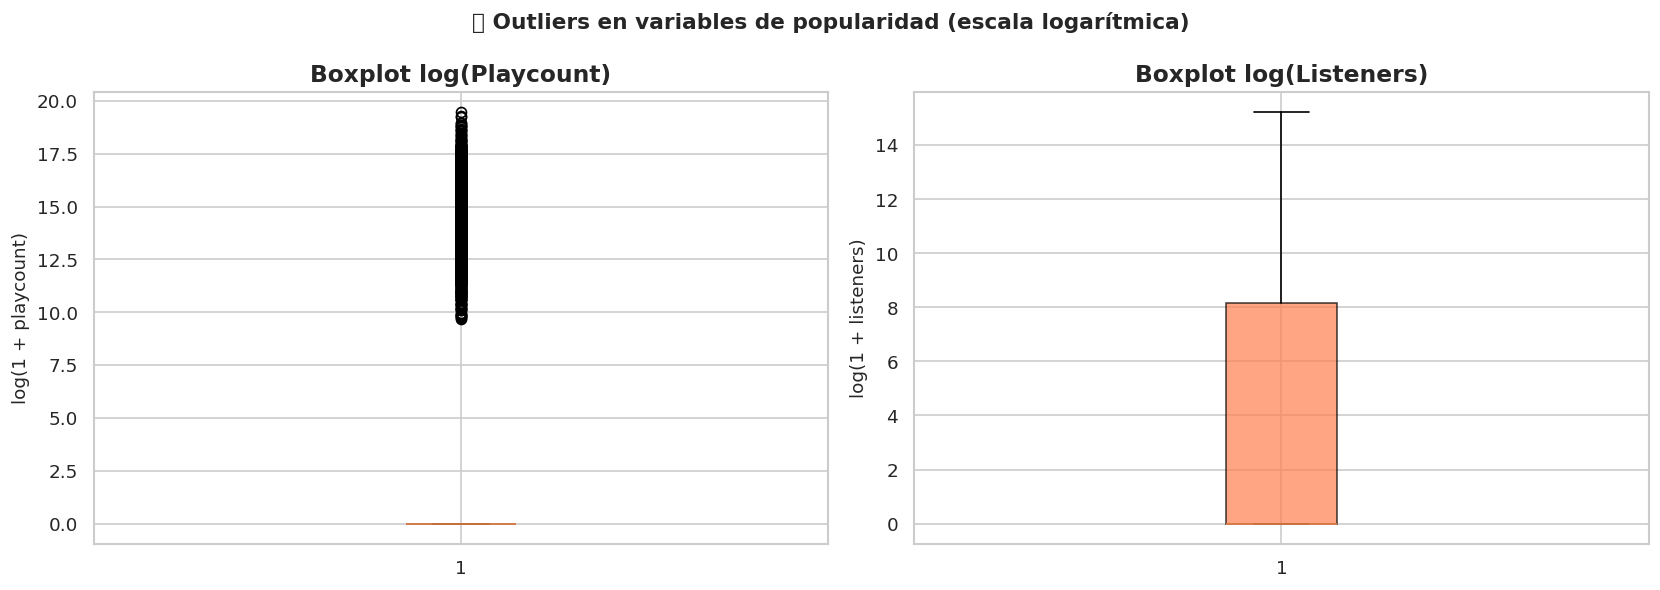

📊 Outliers detectados en log(playcount) con método IQR: 9,999 (16.7%)
   Decisión: NO eliminar outliers en esta fase.
   Razón: un artista muy popular (ej: Sabrina Carpenter) es un outlier real, no un error.
   Para el modelo ML: el log transform ya atenúa su efecto.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot en escala log (más informativo con distribuciones sesgadas)
axes[0].boxplot(df_clean['playcount_log'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[0].set_title('Boxplot log(Playcount)')
axes[0].set_ylabel('log(1 + playcount)')

axes[1].boxplot(df_clean['listeners_log'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.7))
axes[1].set_title('Boxplot log(Listeners)')
axes[1].set_ylabel('log(1 + listeners)')

plt.suptitle('🔍 Outliers en variables de popularidad (escala logarítmica)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplots.png', bbox_inches='tight')
plt.show()

# Detección automática de outliers (IQR method)
q1 = df_clean['playcount_log'].quantile(0.25)
q3 = df_clean['playcount_log'].quantile(0.75)
iqr = q3 - q1
n_outliers = ((df_clean['playcount_log'] < q1 - 1.5*iqr) | (df_clean['playcount_log'] > q3 + 1.5*iqr)).sum()
print(f'📊 Outliers detectados en log(playcount) con método IQR: {n_outliers:,} ({n_outliers/len(df_clean)*100:.1f}%)')
print(f'   Decisión: NO eliminar outliers en esta fase.')
print(f'   Razón: un artista muy popular (ej: Sabrina Carpenter) es un outlier real, no un error.')
print(f'   Para el modelo ML: el log transform ya atenúa su efecto.')

### Top artistas: Evolución temporal de la popularidad  (2024)


**Objetivo:** detectar tendencias de crecimiento o caída de popularidad a lo largo del tiempo simulado.  
**Estrategia:** usamos `month_cohort` como eje temporal y analizamos cómo evolucionan las métricas.

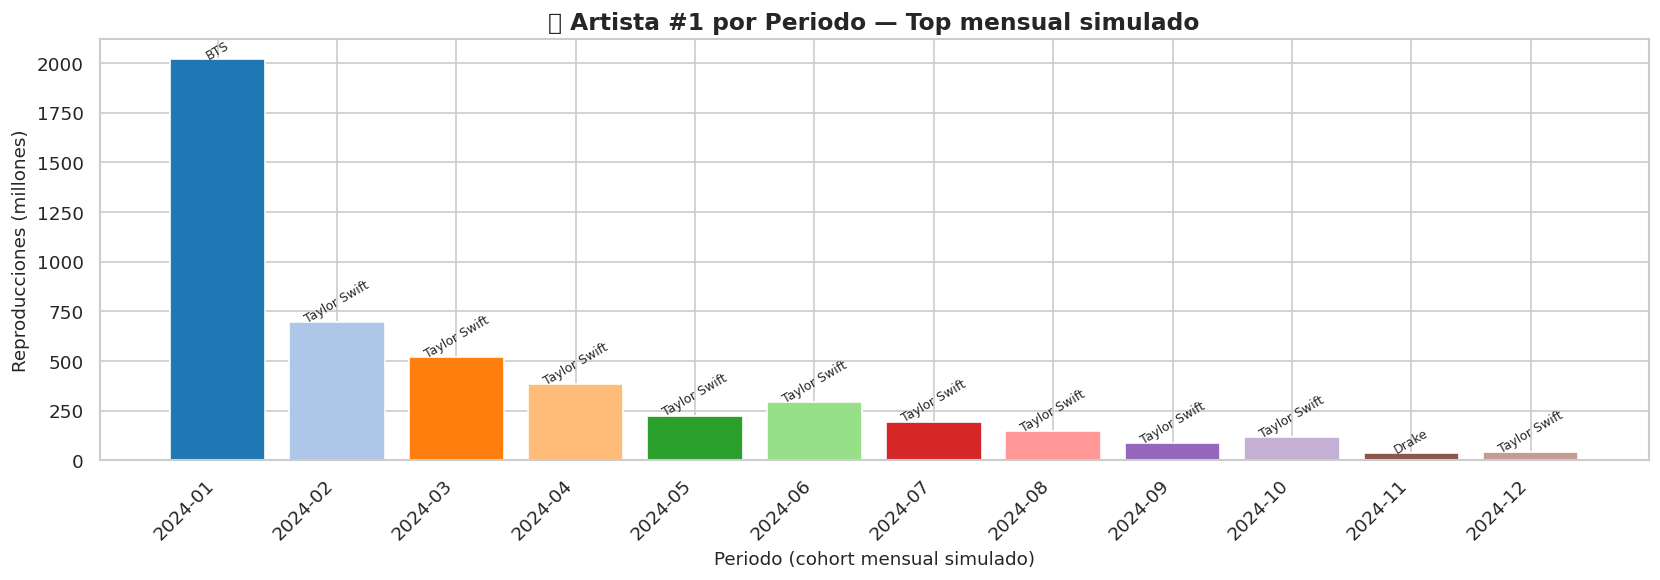

⚠️  Nota metodológica: los periodos son cohorts simulados basados en rank global,
    no fechas reales de streaming. Reflejan la "antigüedad" relativa en el ranking.


In [ ]:

top_by_month = (
    df_clean
    .groupby(['month_cohort', 'artist'])['playcount']
    .sum()
    .reset_index()
    .sort_values(['month_cohort', 'playcount'], ascending=[True, False])
    .groupby('month_cohort')
    .first()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
colors = sns.color_palette('tab20', len(top_by_month))
bars = ax.bar(top_by_month['month_cohort'], top_by_month['playcount'] / 1e6, color=colors)

# Etiqueta del artista sobre cada barra
for bar, row in zip(bars, top_by_month.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            row.artist[:12], ha='center', fontsize=7.5, rotation=30)

ax.set_xlabel('Periodo (cohort mensual simulado)')
ax.set_ylabel('Reproducciones (millones)')
ax.set_title('🎤 Artista #1 por Periodo — Top mensual simulado')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_top_by_month.png', bbox_inches='tight')
plt.show()

print('⚠️  Nota metodológica: los periodos son cohorts simulados basados en rank global,')
print('    no fechas reales de streaming. Reflejan la "antigüedad" relativa en el ranking.')

#### Evolución de métricas clave por periodo

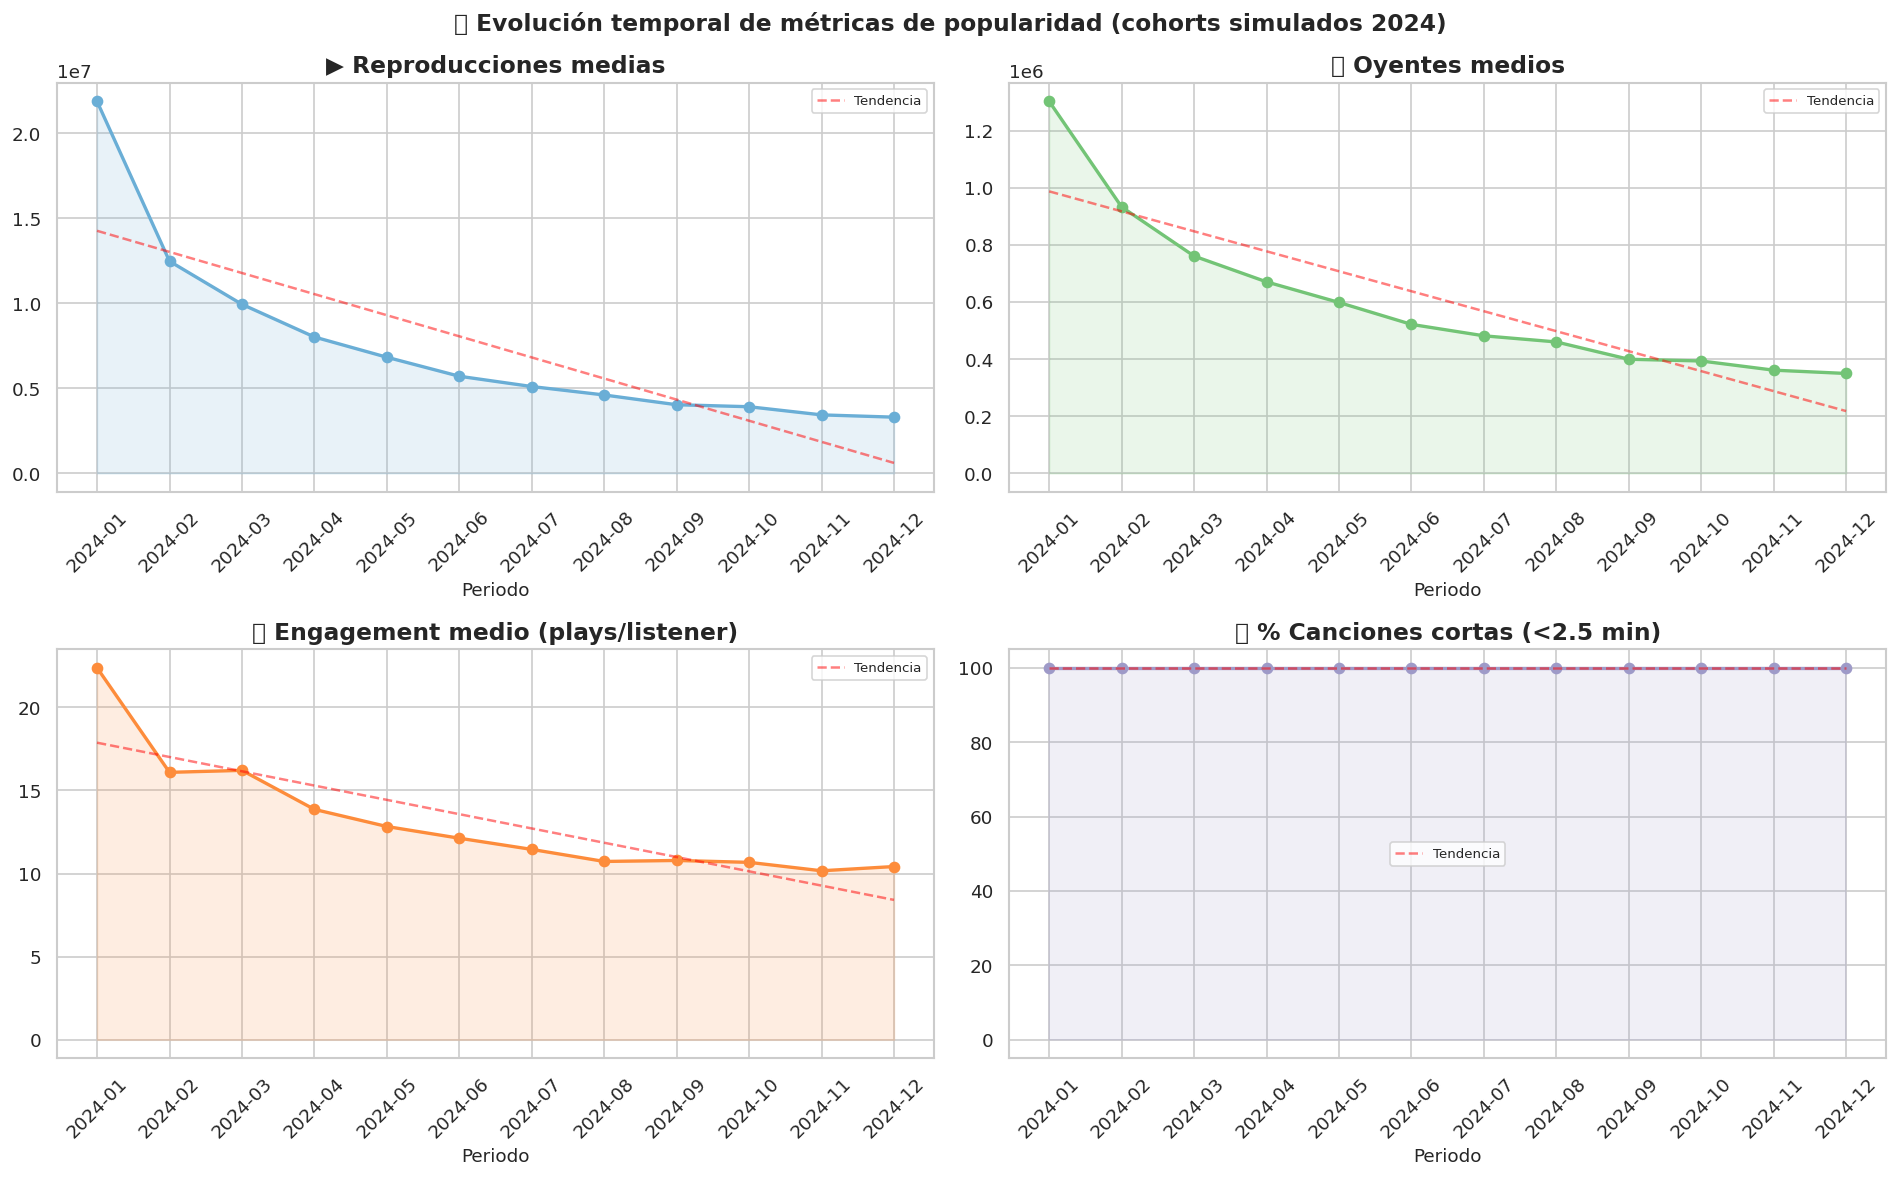


💡 Insights de tendencia:
   Engagement: 📉 decreciente (-11.96 de diferencia inicio→fin del periodo)
   Canciones cortas: 📉 menos predominantes (+0.0pp de cambio)


In [ ]:
monthly_stats = (
    df_clean
    .groupby('month_cohort', observed=True)
    .agg(
        avg_playcount=('playcount', 'mean'),
        avg_listeners=('listeners', 'mean'),
        avg_engagement=('playcount_per_listener', 'mean'),
        n_tracks=('name', 'count'),
        short_track_pct=('is_short_track', 'mean')  # % canciones cortas (<2.5 min)
    )
    .reset_index()
)
monthly_stats['short_track_pct'] *= 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics = [
    ('avg_playcount', 'Reproducciones medias', 'Blues', '▶️'),
    ('avg_listeners', 'Oyentes medios', 'Greens', '👥'),
    ('avg_engagement', 'Engagement medio (plays/listener)', 'Oranges', '🔥'),
    ('short_track_pct', '% Canciones cortas (<2.5 min)', 'Purples', '⏱️'),
]

for ax, (col, label, pal, icon) in zip(axes.flatten(), metrics):
    ax.plot(monthly_stats['month_cohort'], monthly_stats[col],
            marker='o', linewidth=2, color=sns.color_palette(pal, 1)[0])
    ax.fill_between(monthly_stats['month_cohort'], monthly_stats[col],
                    alpha=0.15, color=sns.color_palette(pal, 1)[0])
    ax.set_title(f'{icon} {label}')
    ax.set_xlabel('Periodo')
    ax.tick_params(axis='x', rotation=45)
    # Línea de tendencia (regresión lineal simple)
    x_num = range(len(monthly_stats))
    z = np.polyfit(x_num, monthly_stats[col], 1)
    p = np.poly1d(z)
    ax.plot(monthly_stats['month_cohort'], p(x_num),
            linestyle='--', color='red', alpha=0.5, label='Tendencia')
    ax.legend(fontsize=8)

plt.suptitle('📈 Evolución temporal de métricas de popularidad (cohorts simulados 2024)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_temporal_evolution.png', bbox_inches='tight')
plt.show()

# Insights automáticos
engagement_trend = monthly_stats['avg_engagement'].iloc[-1] - monthly_stats['avg_engagement'].iloc[0]
short_track_trend = monthly_stats['short_track_pct'].iloc[-1] - monthly_stats['short_track_pct'].iloc[0]

print(f'\n💡 Insights de tendencia:')
print(f'   Engagement: {"📈 creciente" if engagement_trend > 0 else "📉 decreciente"} '
      f'({engagement_trend:+.2f} de diferencia inicio→fin del periodo)')
print(f'   Canciones cortas: {"📈 más predominantes" if short_track_trend > 0 else "📉 menos predominantes"} '
      f'({short_track_trend:+.1f}pp de cambio)')

---
## 6. EDA — Relación entre variables <a id='relaciones'></a>

**Objetivo:** entender qué variables están correlacionadas con la popularidad.  
Esto guía el feature selection para los modelos ML.

### Correlación playcount vs listeners 

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample para no sobrecargar el plot
df_sample = df_clean.sample(min(5000, len(df_clean)), random_state=42)

# Scatter en escala log-log
axes[0].scatter(df_sample['listeners_log'], df_sample['playcount_log'],
                alpha=0.2, s=8, color='steelblue')
# Línea de tendencia
z = np.polyfit(df_sample['listeners_log'].dropna(), df_sample['playcount_log'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df_sample['listeners_log'].min(), df_sample['listeners_log'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', alpha=0.7, label=f'Tendencia')
axes[0].set_xlabel('log(Listeners)')
axes[0].set_ylabel('log(Playcount)')
axes[0].set_title('Listeners vs Playcount (log-log)')
axes[0].legend()

# Engagement vs popularidad
engagement_clipped = df_sample['playcount_per_listener'].clip(upper=df_sample['playcount_per_listener'].quantile(0.98))
axes[1].scatter(engagement_clipped, df_sample['playcount_log'],
                alpha=0.2, s=8, color='coral')
axes[1].set_xlabel('Engagement (plays/listener)')
axes[1].set_ylabel('log(Playcount)')
axes[1].set_title('Engagement vs Popularidad')

plt.suptitle('🔗 Relaciones entre variables de popularidad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlaciones.png', bbox_inches='tight')
plt.show()

corr = df_clean[['playcount_log', 'listeners_log', 'playcount_per_listener', 'duration_min']].corr()
r_play_listen = corr.loc['playcount_log', 'listeners_log']
print(f'\n💡 Correlación log(playcount) vs log(listeners): r = {r_play_listen:.3f}')
print(f'   Interpretación: correlación {'muy alta' if abs(r_play_listen) > 0.7 else 'moderada'} — {"las canciones que llegan a más oyentes acumulan más reproducciones" if r_play_listen > 0 else "relación negativa"}')

SyntaxError: f-string: expecting '}' (387154034.py, line 35)

### Heatmap de correlaciones 

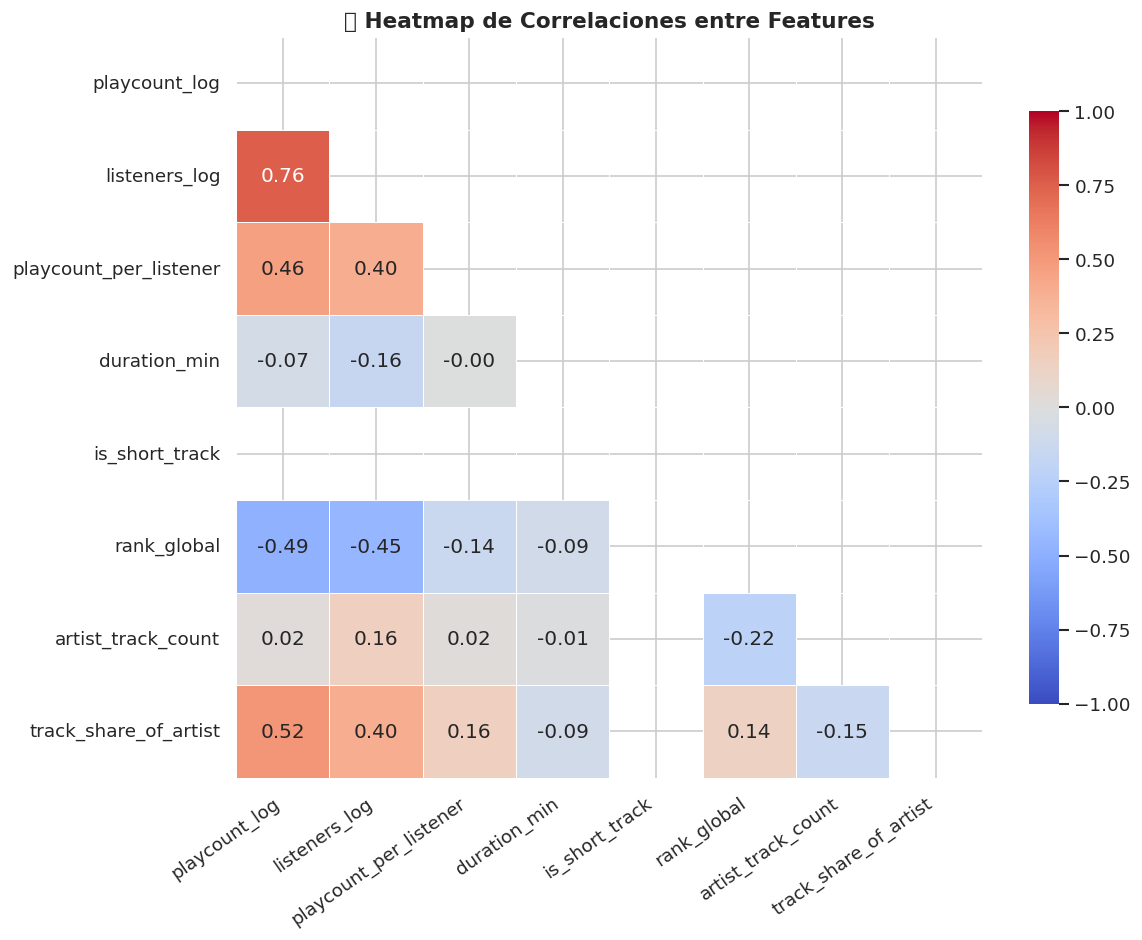


💡 Variables más correlacionadas con log(playcount):
   + listeners_log: |r| = 0.756
   + track_share_of_artist: |r| = 0.517
   - rank_global: |r| = 0.490
   + playcount_per_listener: |r| = 0.462


In [ ]:

numeric_cols = [
    'playcount_log', 'listeners_log', 'playcount_per_listener',
    'duration_min', 'is_short_track', 'rank_global',
    'artist_track_count', 'track_share_of_artist'
]
numeric_cols = [c for c in numeric_cols if c in df_clean.columns]
corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('🔗 Heatmap de Correlaciones entre Features', fontsize=13, fontweight='bold')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('eda_heatmap.png', bbox_inches='tight')
plt.show()

# Top correlaciones con popularidad
corr_con_target = corr_matrix['playcount_log'].drop('playcount_log').abs().sort_values(ascending=False)
print('\n💡 Variables más correlacionadas con log(playcount):')
for feat, r in corr_con_target.head(4).items():
    signo = '+' if corr_matrix.loc['playcount_log', feat] > 0 else '-'
    print(f'   {signo} {feat}: |r| = {r:.3f}')

### Duración vs popularidad 
* CORRECCIÓN detectada: en el backup, la duración se imprimía en segundos pero se etiquetaba como 'minutos'. Aquí ya está corregido (dividimos por 60).

* DUDA: no detecta las labels?

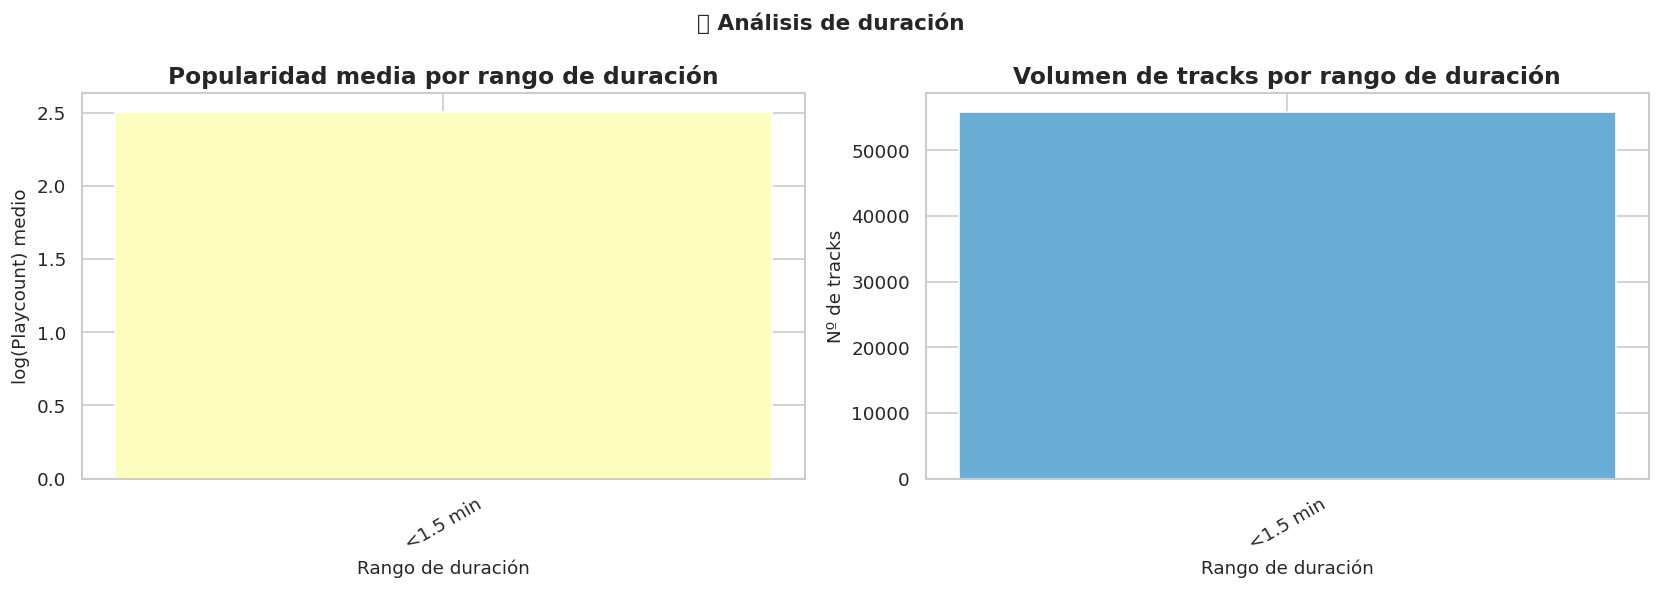


💡 Canciones cortas (<2.5 min): 100.0% del dataset
   Popularidad media: cortas=2.559  |  largas=nan
   → Las canciones largas tienen mayor popularidad media en este dataset.


In [ ]:
df_clean['duration_bucket'] = pd.cut(
    df_clean['duration_min'],
    bins=[0, 1.5, 2.5, 3.5, 4.5, 6, 100],
    labels=['<1.5 min', '1.5-2.5 min', '2.5-3.5 min', '3.5-4.5 min', '4.5-6 min', '>6 min']
)

dur_pop = (
    df_clean
    .groupby('duration_bucket', observed=True)['playcount_log']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dur_pop['duration_bucket'], dur_pop['mean'],
            color=sns.color_palette('RdYlGn', len(dur_pop)))
axes[0].set_xlabel('Rango de duración')
axes[0].set_ylabel('log(Playcount) medio')
axes[0].set_title('Popularidad media por rango de duración')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(dur_pop['duration_bucket'], dur_pop['count'],
            color=sns.color_palette('Blues', len(dur_pop)))
axes[1].set_xlabel('Rango de duración')
axes[1].set_ylabel('Nº de tracks')
axes[1].set_title('Volumen de tracks por rango de duración')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('⏱️ Análisis de duración', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_duracion.png', bbox_inches='tight')
plt.show()

pct_short = df_clean['is_short_track'].mean() * 100
print(f'\n💡 Canciones cortas (<2.5 min): {pct_short:.1f}% del dataset')
short_pop  = df_clean[df_clean['is_short_track'] == 1]['playcount_log'].mean()
long_pop   = df_clean[df_clean['is_short_track'] == 0]['playcount_log'].mean()
winner = 'cortas' if short_pop > long_pop else 'largas'
print(f'   Popularidad media: cortas={short_pop:.3f}  |  largas={long_pop:.3f}')
print(f'   → Las canciones {winner} tienen mayor popularidad media en este dataset.')

---
## 7. EDA — Análisis por país <a id='pais'></a>

**Objetivo:** identificar los mercados con mayor consumo y detectar diferencias culturales en preferencias musicales.  
⚠️ Sesgo a considerar: los datos provienen de `geo.getTopTracks` — cada país tiene el mismo número de páginas, lo que puede sobrerepresentar mercados pequeños.

### Consumo por país

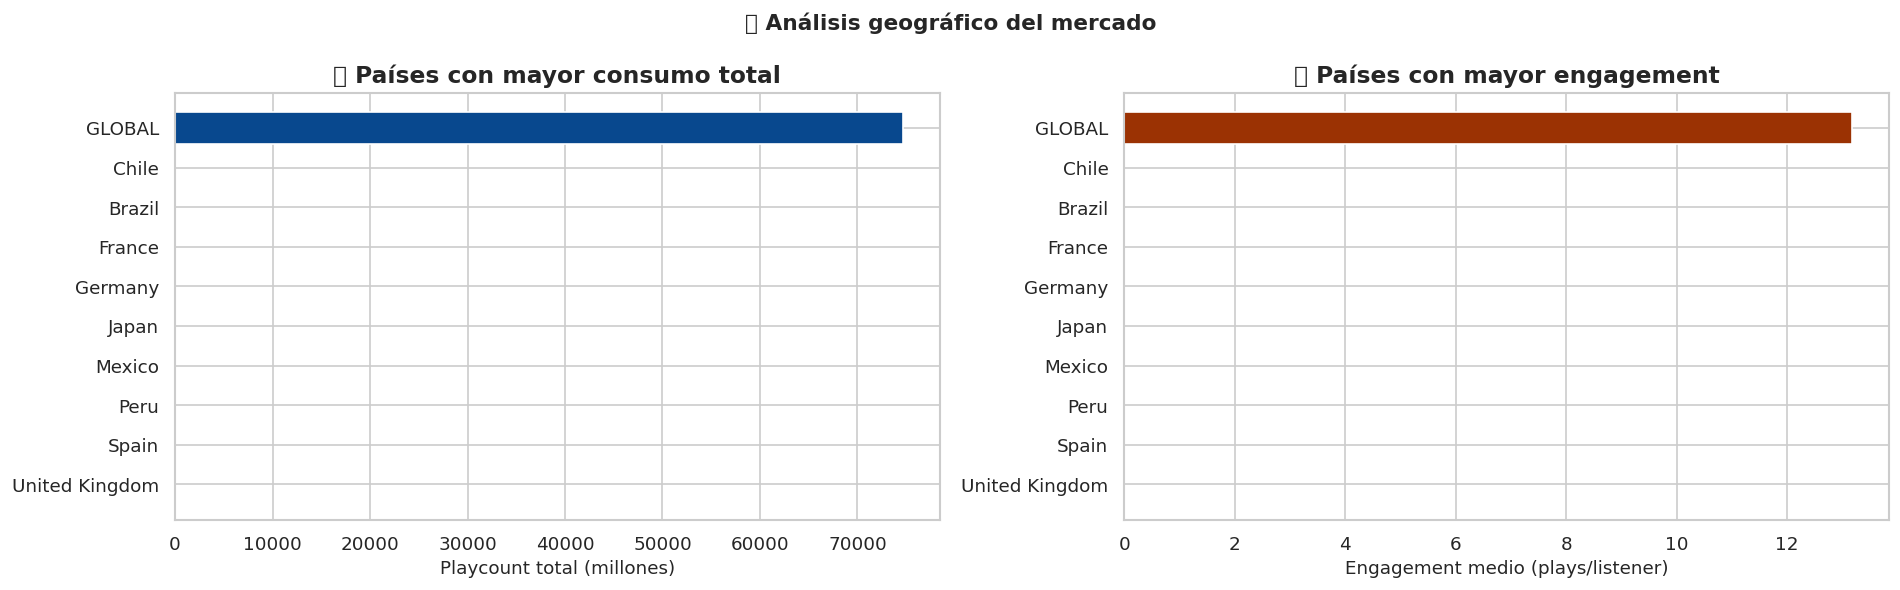


💡 País con mayor consumo: GLOBAL (74694.5M plays)

⚠️  Sesgo: geo.getTopTracks devuelve el mismo nº de páginas por país.
   Los países con más tracks en el dataset no necesariamente consumen más música globalmente.


In [ ]:

df_geo = df_clean[df_clean['country'] != 'UNKNOWN'].copy()

country_stats = (
    df_geo
    .groupby('country')
    .agg(
        n_tracks       = ('name', 'count'),
        total_playcount= ('playcount', 'sum'),
        avg_playcount  = ('playcount', 'mean'),
        avg_engagement = ('playcount_per_listener', 'mean'),
    )
    .sort_values('total_playcount', ascending=False)
    .reset_index()
)

if len(country_stats) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].barh(country_stats.head(10)['country'],
                 country_stats.head(10)['total_playcount'] / 1e6,
                 color=sns.color_palette('Blues_r', 10))
    axes[0].invert_yaxis()
    axes[0].set_xlabel('Playcount total (millones)')
    axes[0].set_title('🌍 Países con mayor consumo total')

    top10_eng = country_stats.sort_values('avg_engagement', ascending=False).head(10)
    axes[1].barh(top10_eng['country'], top10_eng['avg_engagement'],
                 color=sns.color_palette('Oranges_r', 10))
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Engagement medio (plays/listener)')
    axes[1].set_title('🔥 Países con mayor engagement')

    plt.suptitle('📊 Análisis geográfico del mercado', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_geo.png', bbox_inches='tight')
    plt.show()

    top_pais = country_stats.iloc[0]
    print(f'\n💡 País con mayor consumo: {top_pais["country"]} ({top_pais["total_playcount"]/1e6:.1f}M plays)')
    print(f'\n⚠️  Sesgo: geo.getTopTracks devuelve el mismo nº de páginas por país.')
    print(f'   Los países con más tracks en el dataset no necesariamente consumen más música globalmente.')
else:
    print('ℹ️  No hay datos geográficos disponibles (todas las filas tienen country=UNKNOWN).')
    print('   Para habilitar este análisis, incluir el endpoint geo.getTopTracks en la recolección.')

### Heatmap géneros × país

In [ ]:

df_geo_genre = df_clean[
    (df_clean['country'] != 'UNKNOWN') & (df_clean['genre_tag'] != 'UNKNOWN')
].copy()

if len(df_geo_genre) > 50:  # solo tiene sentido con suficientes datos
    pivot = (
        df_geo_genre
        .groupby(['country', 'genre_tag'])['playcount']
        .sum()
        .unstack(fill_value=0)
    )
    # Normalizar por fila: preferencia relativa (no volumen absoluto)
    pivot_norm = pivot.div(pivot.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(pivot_norm, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': '% del consumo del país'})
    ax.set_title('🌍 Distribución de géneros por país (% del consumo)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Género')
    ax.set_ylabel('País')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig('eda_geo_genre_heatmap.png', bbox_inches='tight')
    plt.show()
else:
    print('ℹ️  Datos insuficientes para el heatmap género×país.')
    print('   Necesitas tracks con country AND genre_tag distintos de UNKNOWN.')

ℹ️  Datos insuficientes para el heatmap género×país.
   Necesitas tracks con country AND genre_tag distintos de UNKNOWN.


---
## 8. EDA — Análisis por género <a id='genero'></a>

**Objetivo:** detectar géneros dominantes, géneros emergentes y géneros en declive.  
Diferenciamos entre **volumen** (cuántos tracks) y **éxito** (popularidad media) — pueden no coincidir.

### Géneros más frecuentes vs más populares

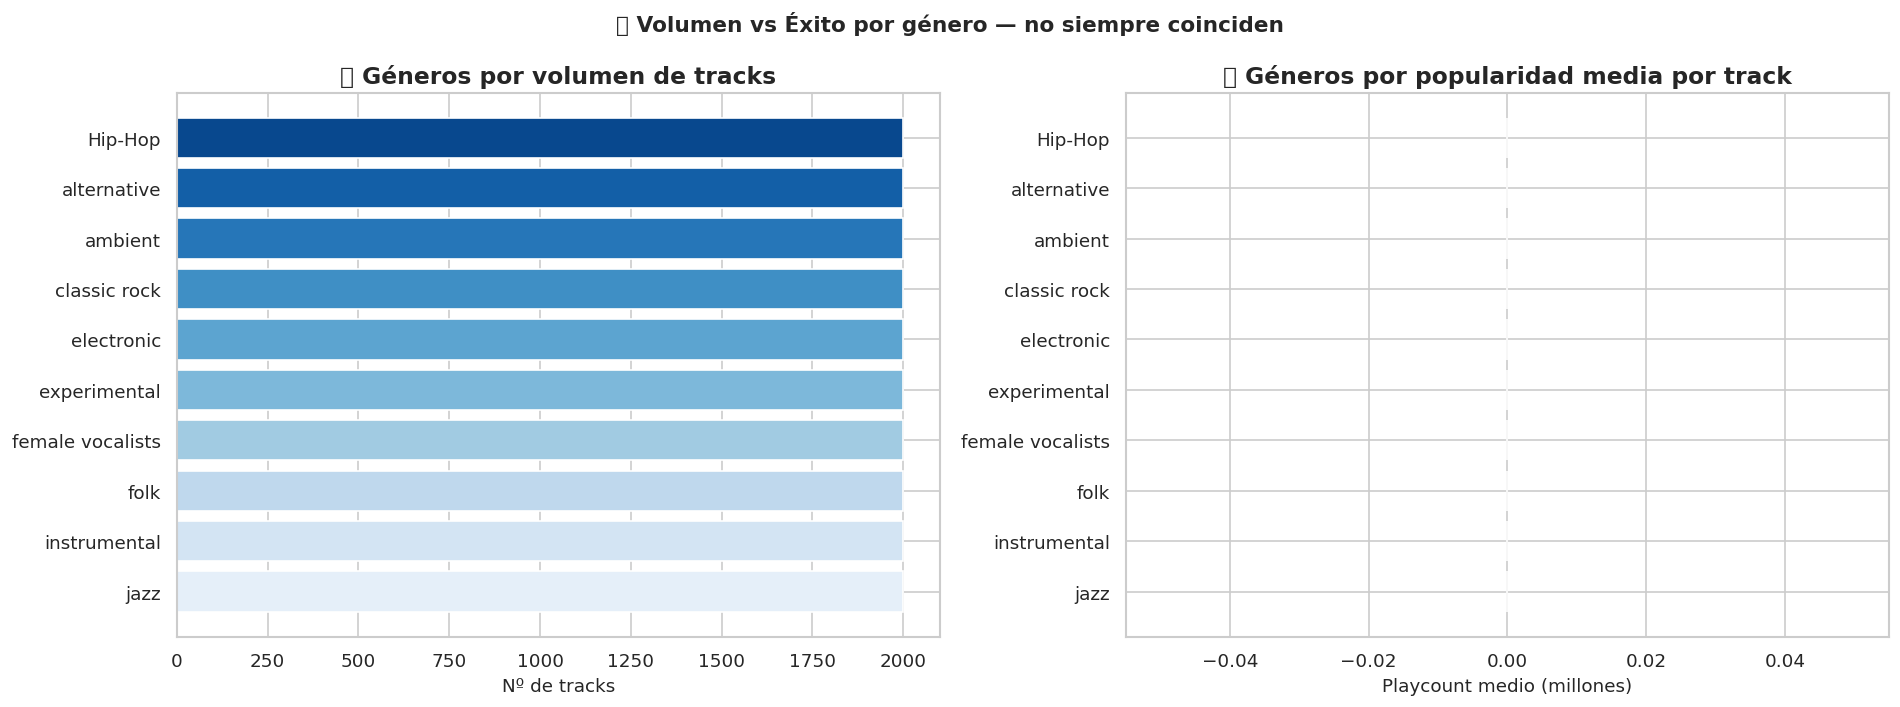

💡 Clave: el género con más tracks NO es necesariamente el más popular.
   Un género con pocos tracks pero alta popularidad media tiene mucho potencial de mercado.


In [ ]:

df_gen = df_clean[df_clean['genre_tag'] != 'UNKNOWN'].copy()
genre_stats = (
    df_gen
    .groupby('genre_tag')
    .agg(
        n_tracks       = ('name', 'count'),
        avg_playcount  = ('playcount', 'mean'),
        total_playcount= ('playcount', 'sum'),
        avg_engagement = ('playcount_per_listener', 'mean'),
        pct_short      = ('is_short_track', 'mean'),
    )
    .reset_index()
)
genre_stats['pct_short'] *= 100

top10_vol     = genre_stats.sort_values('n_tracks', ascending=False).head(10)
top10_popular = genre_stats.sort_values('avg_playcount', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por volumen
axes[0].barh(top10_vol['genre_tag'], top10_vol['n_tracks'],
             color=sns.color_palette('Blues_r', 10))
axes[0].invert_yaxis()
axes[0].set_xlabel('Nº de tracks')
axes[0].set_title('📦 Géneros por volumen de tracks')

# Por popularidad media
axes[1].barh(top10_popular['genre_tag'], top10_popular['avg_playcount'] / 1e6,
             color=sns.color_palette('Oranges_r', 10))
axes[1].invert_yaxis()
axes[1].set_xlabel('Playcount medio (millones)')
axes[1].set_title('⭐ Géneros por popularidad media por track')

plt.suptitle('🎵 Volumen vs Éxito por género — no siempre coinciden', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_generos.png', bbox_inches='tight')
plt.show()

print('💡 Clave: el género con más tracks NO es necesariamente el más popular.')
print('   Un género con pocos tracks pero alta popularidad media tiene mucho potencial de mercado.')

### Comparativa multi-métrica por género 

* Comparamos la presencia de cada género en la primera mitad del ranking
* vs la segunda mitad. Si un género tiene más tracks en el top 50%,
* es emergente. Si los tiene en el fondo, está en declive.

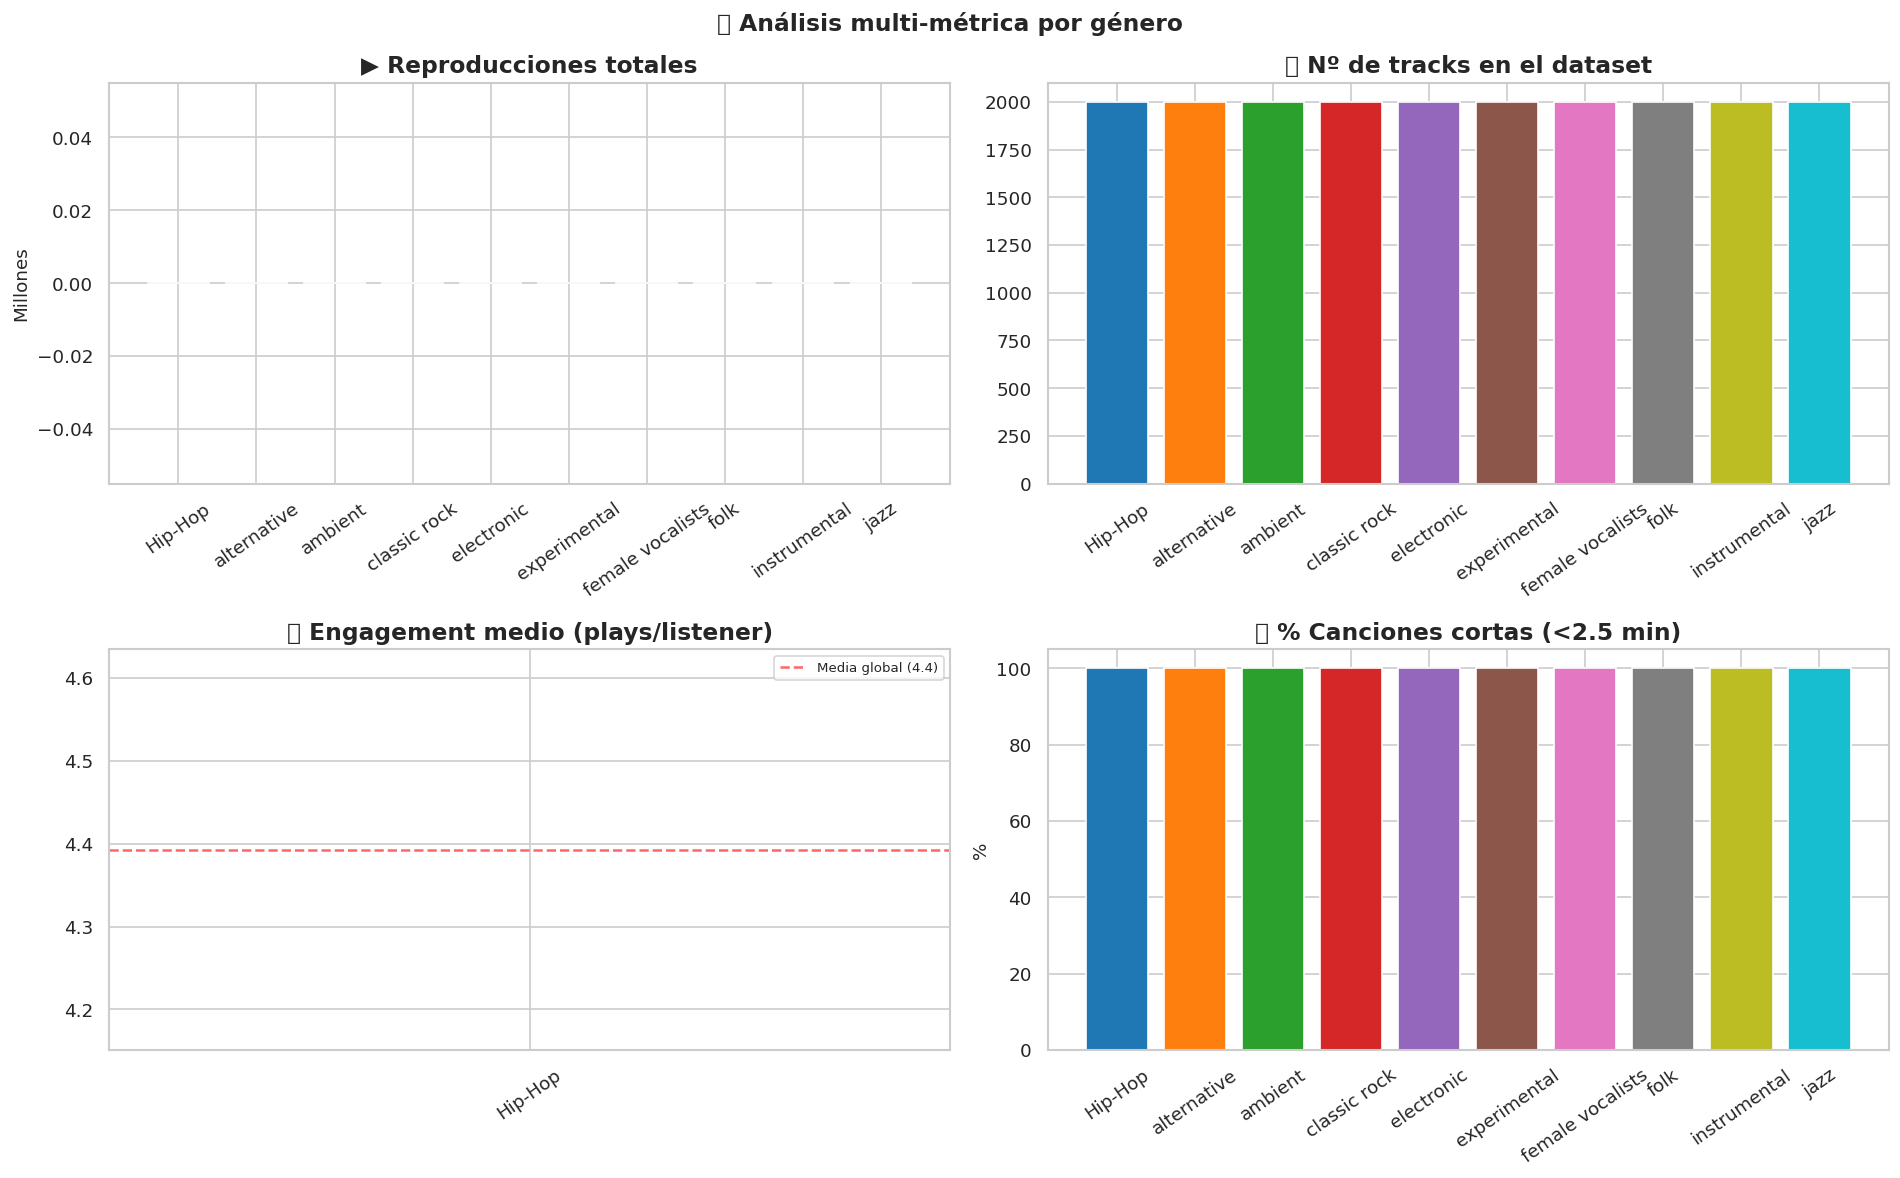

In [ ]:

top10_g = genre_stats.sort_values('total_playcount', ascending=False).head(10)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
palette = sns.color_palette('tab10', 10)

# Reproducciones totales
axes[0, 0].bar(top10_g['genre_tag'], top10_g['total_playcount'] / 1e6, color=palette)
axes[0, 0].set_title('▶️ Reproducciones totales')
axes[0, 0].set_ylabel('Millones')
axes[0, 0].tick_params(axis='x', rotation=35)

# Nº tracks
axes[0, 1].bar(top10_g['genre_tag'], top10_g['n_tracks'], color=palette)
axes[0, 1].set_title('📦 Nº de tracks en el dataset')
axes[0, 1].tick_params(axis='x', rotation=35)

# Engagement
media_global = df_clean['playcount_per_listener'].mean()
axes[1, 0].bar(top10_g['genre_tag'], top10_g['avg_engagement'], color=palette)
axes[1, 0].axhline(media_global, color='red', linestyle='--', alpha=0.6, label=f'Media global ({media_global:.1f})')
axes[1, 0].set_title('🔥 Engagement medio (plays/listener)')
axes[1, 0].tick_params(axis='x', rotation=35)
axes[1, 0].legend(fontsize=8)

# % canciones cortas
axes[1, 1].bar(top10_g['genre_tag'], top10_g['pct_short'], color=palette)
axes[1, 1].set_title('⏱️ % Canciones cortas (<2.5 min)')
axes[1, 1].set_ylabel('%')
axes[1, 1].tick_params(axis='x', rotation=35)

plt.suptitle('🎵 Análisis multi-métrica por género', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_generos_multimetrica.png', bbox_inches='tight')
plt.show()

### Géneros emergentes vs en declive 
*  Proxy: si un género tiene sus tracks concentrados en los primeros puestos del ranking global → está en tendencia ahora.

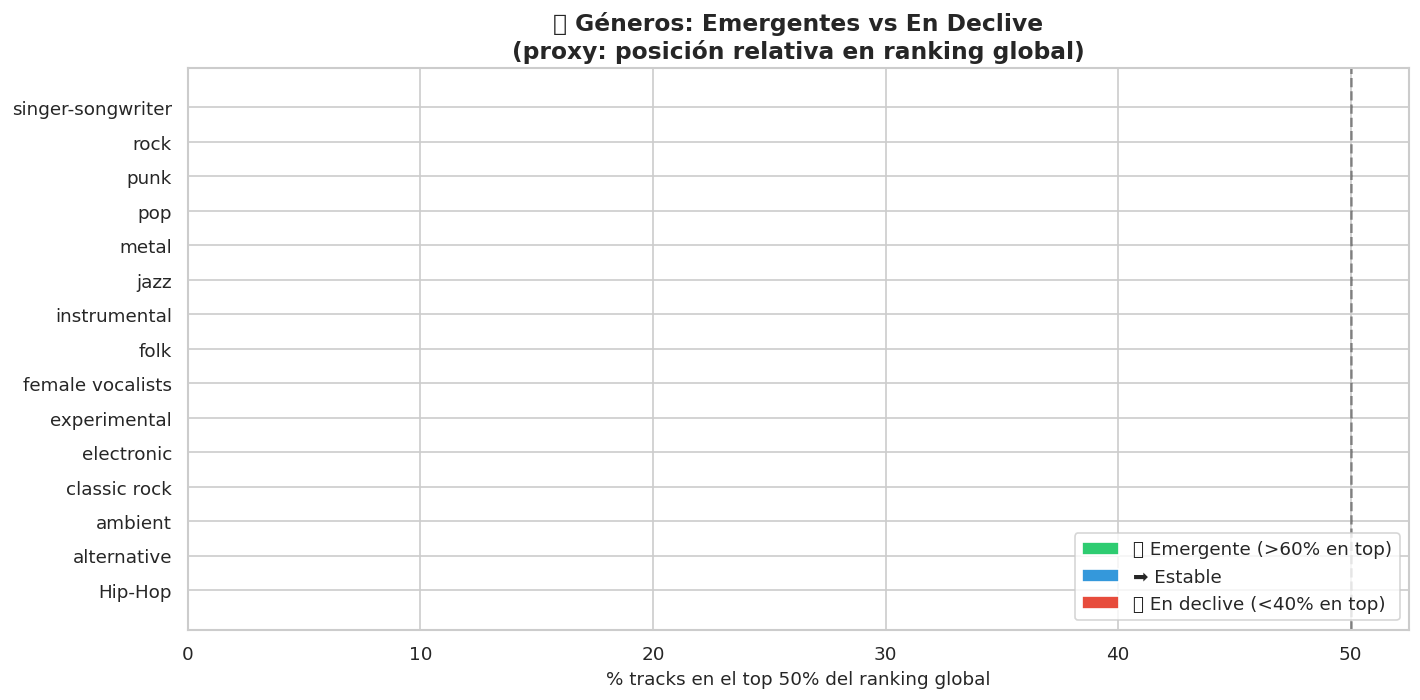


💡 Géneros emergentes: []
   Géneros en declive: ['Hip-Hop', 'alternative', 'ambient', 'classic rock', 'electronic', 'experimental', 'female vocalists', 'folk', 'instrumental', 'jazz', 'metal', 'pop', 'punk', 'rock', 'singer-songwriter']


In [ ]:


median_rank = df_clean['rank_global'].median()

genre_growth = (
    df_gen
    .assign(is_trending=(df_gen['rank_global'] <= median_rank).astype(int))
    .groupby('genre_tag')
    .agg(
        pct_trending=('is_trending', 'mean'),
        n_tracks    =('name', 'count'),
    )
    .query('n_tracks >= 5')  # solo géneros con masa suficiente para ser significativos
    .sort_values('pct_trending', ascending=False)
    .reset_index()
)
genre_growth['pct_trending'] *= 100
genre_growth['status'] = genre_growth['pct_trending'].apply(
    lambda x: '🚀 Emergente' if x > 60 else ('📉 En declive' if x < 40 else '➡️ Estable')
)

color_map = {'🚀 Emergente': '#2ecc71', '➡️ Estable': '#3498db', '📉 En declive': '#e74c3c'}
colors = genre_growth['status'].map(color_map)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(genre_growth['genre_tag'], genre_growth['pct_trending'], color=colors)
ax.axvline(50, color='black', linestyle='--', alpha=0.4, label='Línea de equilibrio (50%)')
ax.set_xlabel('% tracks en el top 50% del ranking global')
ax.set_title('📊 Géneros: Emergentes vs En Declive\n(proxy: posición relativa en ranking global)',
             fontweight='bold')

from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#2ecc71', label='🚀 Emergente (>60% en top)'),
              Patch(facecolor='#3498db', label='➡️ Estable'),
              Patch(facecolor='#e74c3c', label='📉 En declive (<40% en top)')]
ax.legend(handles=legend_els, loc='lower right')
plt.tight_layout()
plt.savefig('eda_generos_crecimiento.png', bbox_inches='tight')
plt.show()

emergentes = genre_growth[genre_growth['status'] == '🚀 Emergente']['genre_tag'].tolist()
en_declive = genre_growth[genre_growth['status'] == '📉 En declive']['genre_tag'].tolist()
print(f'\n💡 Géneros emergentes: {emergentes}')
print(f'   Géneros en declive: {en_declive}')
if emergentes:
    print(f'\n🎯 Recomendación de negocio: apostar por {", ".join(emergentes[:3])} para maximizar visibilidad.')

**Objetivo:** identificar qué géneros están dominando el mercado, cuáles están en declive y cuáles son emergentes.

### Vista general de géneros

*  Excluimos UNKNOWN para el análisis de géneros

In [ ]:
df_genres = df_clean[df_clean['genre_tag'] != 'UNKNOWN'].copy()

genre_stats = (
    df_genres
    .groupby('genre_tag')
    .agg(
        n_tracks=('name', 'count'),
        total_playcount=('playcount', 'sum'),
        avg_playcount=('playcount', 'mean'),
        avg_listeners=('listeners', 'mean'),
        avg_engagement=('playcount_per_listener', 'mean'),
        pct_short=('is_short_track', 'mean')
    )
    .sort_values('total_playcount', ascending=False)
    .reset_index()
)
genre_stats['pct_short'] *= 100

print(f'📊 Géneros en el dataset: {len(genre_stats)}')
display(genre_stats.head(10))

📊 Géneros en el dataset: 15


,genre_tag,n_tracks,total_playcount,avg_playcount,avg_listeners,avg_engagement,pct_short
0,Hip-Hop,1513,0,0.0,0.0,NaN,100.0
1,alternative,1014,0,0.0,0.0,NaN,100.0
2,ambient,1892,0,0.0,0.0,NaN,100.0
3,classic rock,1774,0,0.0,0.0,NaN,100.0
4,electronic,1062,0,0.0,0.0,NaN,100.0
5,experimental,1650,0,0.0,0.0,NaN,100.0
6,female vocalists,1112,0,0.0,0.0,NaN,100.0
7,folk,1164,0,0.0,0.0,NaN,100.0
8,instrumental,1749,0,0.0,0.0,NaN,100.0
9,jazz,1933,0,0.0,0.0,NaN,100.0


### Comparativa visual entre géneros

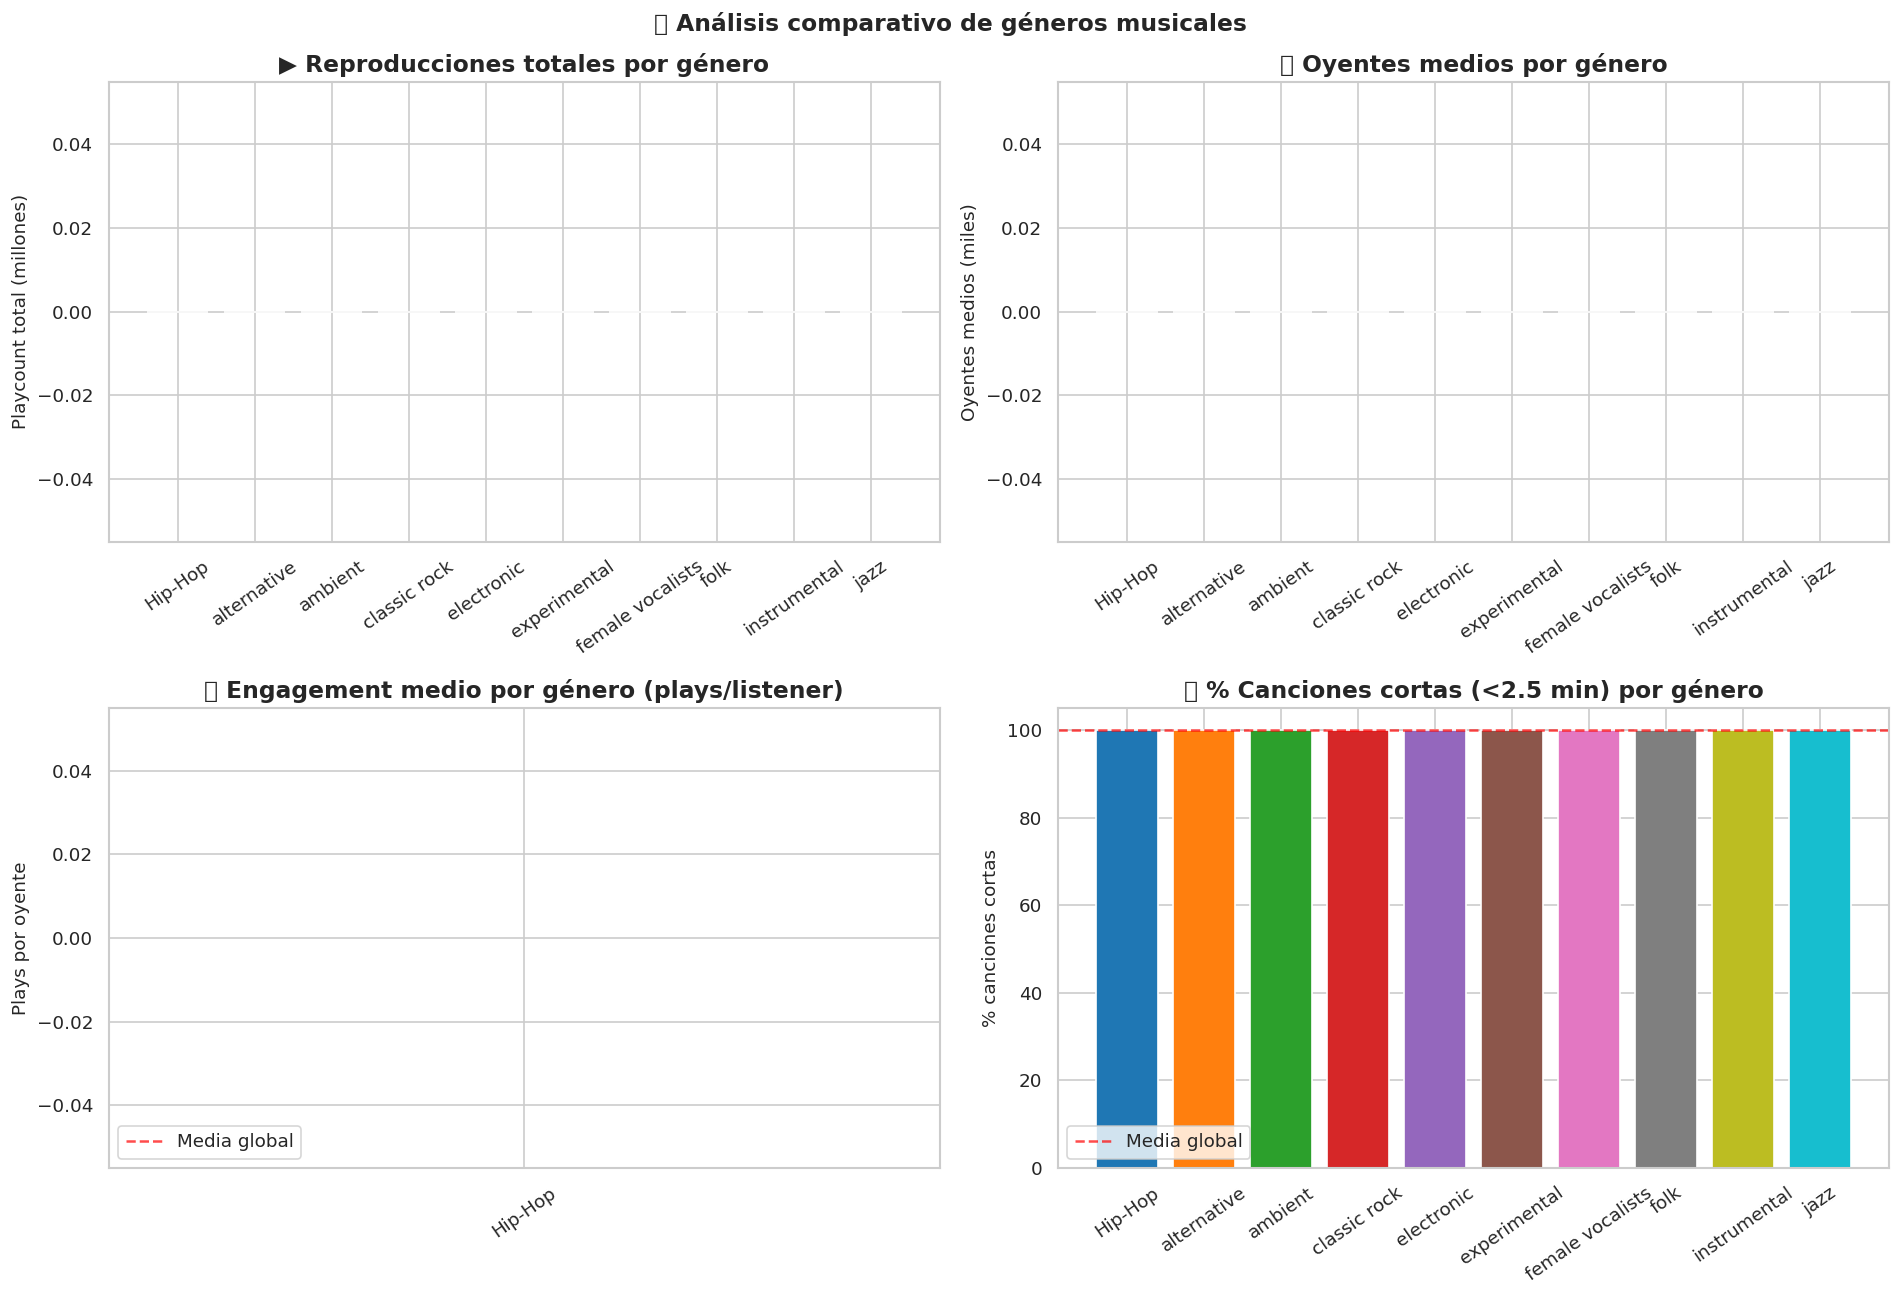

In [ ]:

top_genres = genre_stats.head(10)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

palette = sns.color_palette('tab10', 10)

# Reproducciones totales
axes[0, 0].bar(top_genres['genre_tag'], top_genres['total_playcount'] / 1e6, color=palette)
axes[0, 0].set_title('▶️ Reproducciones totales por género')
axes[0, 0].set_ylabel('Playcount total (millones)')
axes[0, 0].tick_params(axis='x', rotation=35)

# Oyentes medios
axes[0, 1].bar(top_genres['genre_tag'], top_genres['avg_listeners'] / 1e3, color=palette)
axes[0, 1].set_title('👤 Oyentes medios por género')
axes[0, 1].set_ylabel('Oyentes medios (miles)')
axes[0, 1].tick_params(axis='x', rotation=35)

# Engagement
axes[1, 0].bar(top_genres['genre_tag'], top_genres['avg_engagement'], color=palette)
axes[1, 0].set_title('🔥 Engagement medio por género (plays/listener)')
axes[1, 0].set_ylabel('Plays por oyente')
axes[1, 0].tick_params(axis='x', rotation=35)
axes[1, 0].axhline(genre_stats['avg_engagement'].mean(), color='red',
                   linestyle='--', alpha=0.7, label='Media global')
axes[1, 0].legend()

# % Canciones cortas
axes[1, 1].bar(top_genres['genre_tag'], top_genres['pct_short'], color=palette)
axes[1, 1].set_title('⏱️ % Canciones cortas (<2.5 min) por género')
axes[1, 1].set_ylabel('% canciones cortas')
axes[1, 1].tick_params(axis='x', rotation=35)
axes[1, 1].axhline(df_clean['is_short_track'].mean() * 100, color='red',
                   linestyle='--', alpha=0.7, label='Media global')
axes[1, 1].legend()

plt.suptitle('🎵 Análisis comparativo de géneros musicales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_genre_comparison.png', bbox_inches='tight')
plt.show()

### Evolución de géneros por periodo

* Top 5 géneros y su evolución mensual (basado en playcount medio)

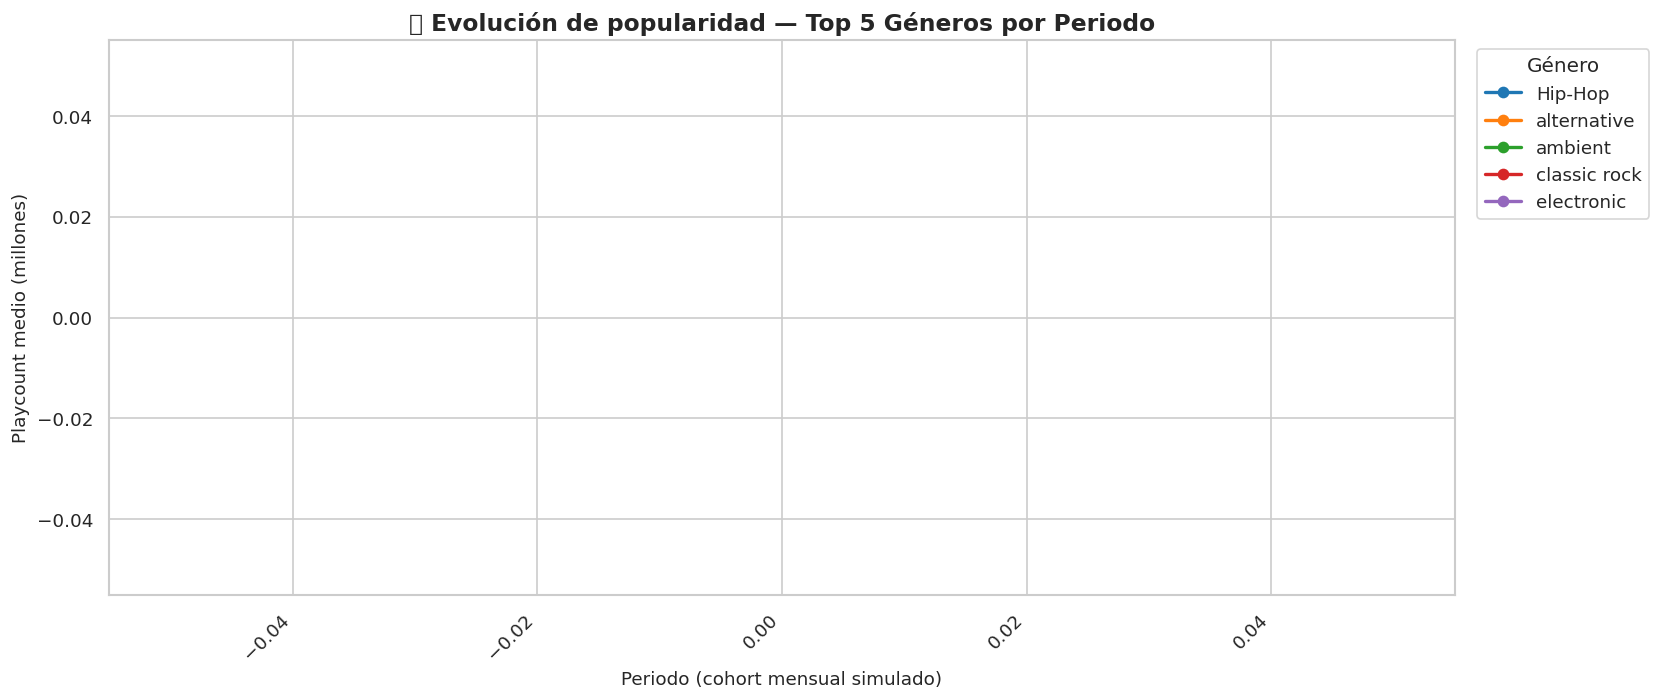

In [ ]:

top5_genres = genre_stats.head(5)['genre_tag'].tolist()

genre_monthly = (
    df_genres[df_genres['genre_tag'].isin(top5_genres)]
    .groupby(['month_cohort', 'genre_tag'], observed=True)['playcount']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

for genre, color in zip(top5_genres, sns.color_palette('tab10', 5)):
    data = genre_monthly[genre_monthly['genre_tag'] == genre]
    ax.plot(data['month_cohort'], data['playcount'] / 1e6,
            marker='o', label=genre, linewidth=2, color=color)

ax.set_xlabel('Periodo (cohort mensual simulado)')
ax.set_ylabel('Playcount medio (millones)')
ax.set_title('📈 Evolución de popularidad — Top 5 Géneros por Periodo')
ax.legend(title='Género', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_genre_evolution.png', bbox_inches='tight')
plt.show()

## 5. Correlaciones

+ **Objetivo:** Entender qué variables están correlacionadas entre sí y con la popularidad. Esto guía el feature selection para los modelos ML.

### Heatmap de correlaciones

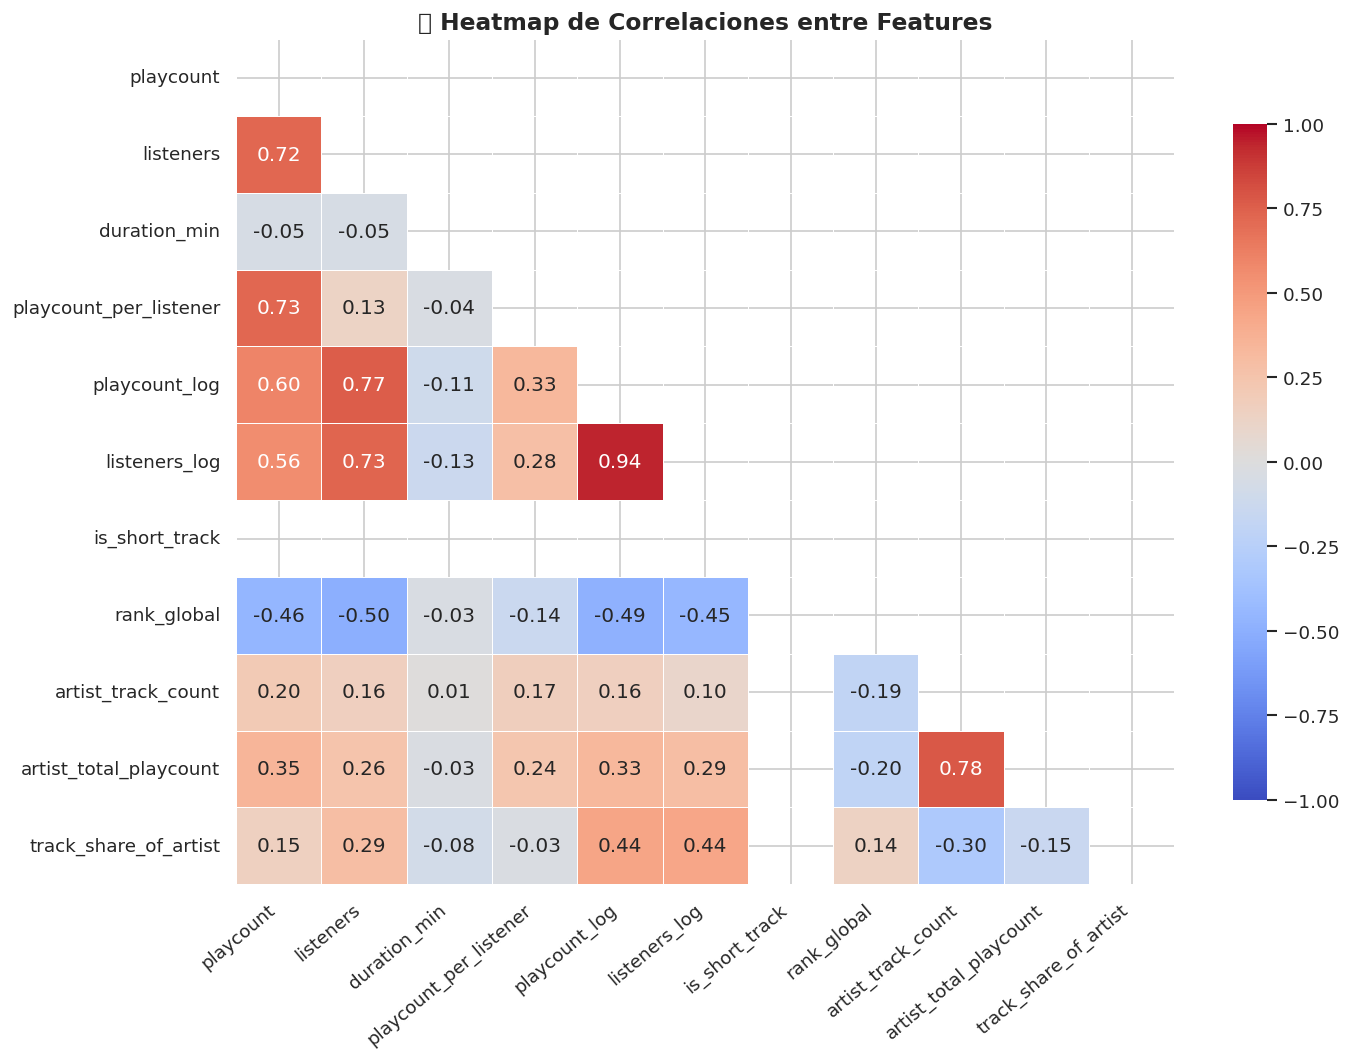


💡 Variables más correlacionadas con playcount (popularidad):
   + playcount_per_listener: r=0.726
   + listeners: r=0.721
   + playcount_log: r=0.600
   + listeners_log: r=0.557
   - rank_global: r=-0.461


In [ ]:
numeric_cols = [
    'playcount', 'listeners', 'duration_min',
    'playcount_per_listener', 'playcount_log', 'listeners_log',
    'is_short_track', 'rank_global', 'artist_track_count',
    'artist_total_playcount', 'track_share_of_artist'
]
# Nos quedamos con las que existen en df_clean
numeric_cols = [c for c in numeric_cols if c in df_clean.columns]

corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # ocultamos triángulo superior
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('🔗 Heatmap de Correlaciones entre Features', fontweight='bold', fontsize=14)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Insights: correlaciones más altas con playcount
corr_with_playcount = corr_matrix['playcount'].drop('playcount').abs().sort_values(ascending=False)
print('\n💡 Variables más correlacionadas con playcount (popularidad):')
for feat, val in corr_with_playcount.head(5).items():
    direction = '+' if corr_matrix['playcount'][feat] > 0 else '-'
    print(f'   {direction} {feat}: r={corr_matrix["playcount"][feat]:.3f}')

### Scatter plots de relaciones clave

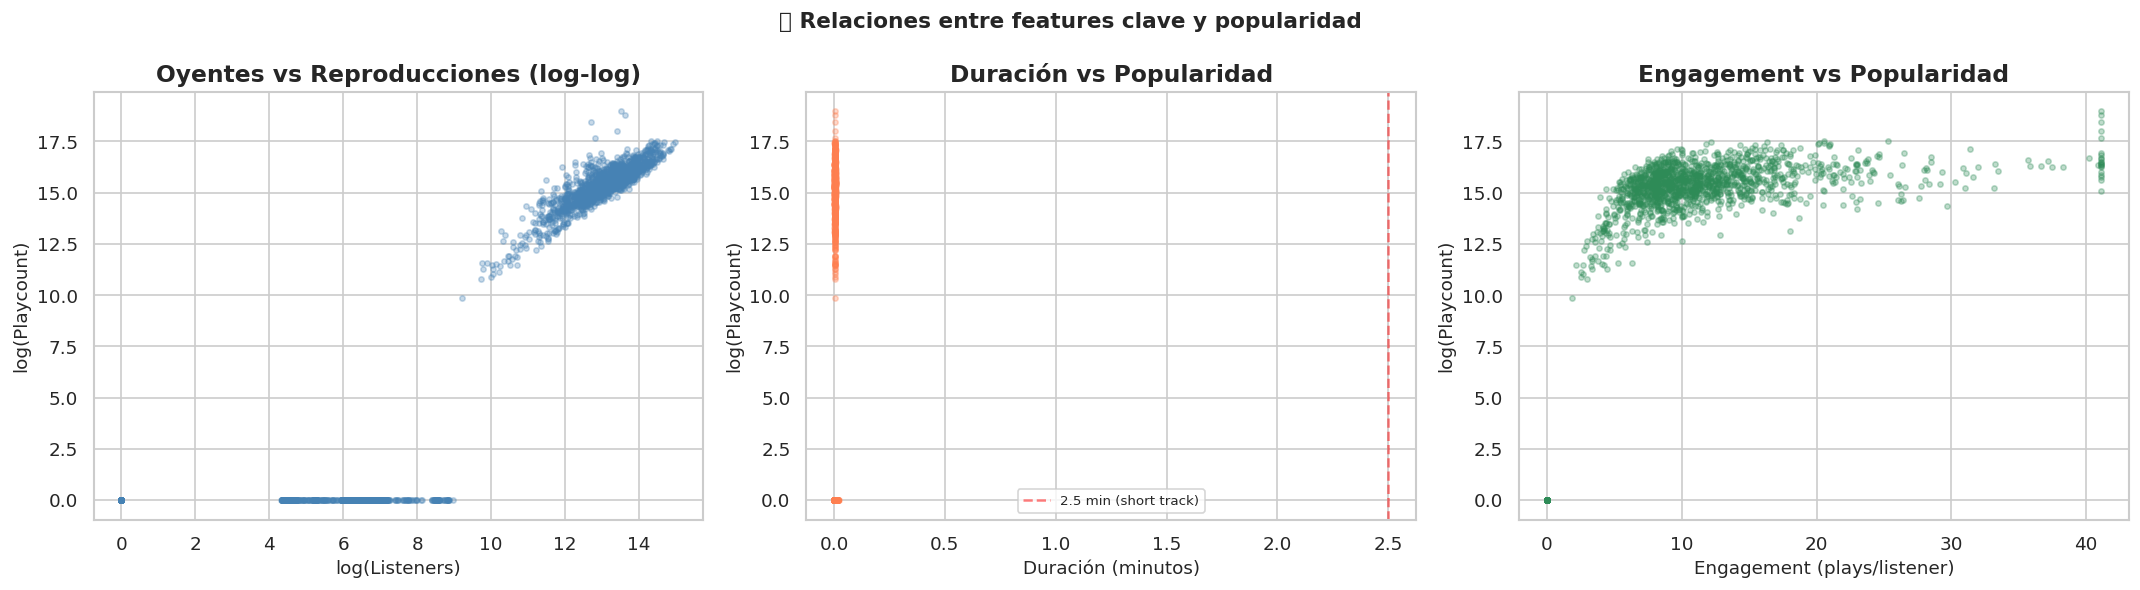

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sample para no sobrecargar el plot
df_sample = df_clean.sample(min(5000, len(df_clean)), random_state=42)

# Listeners vs Playcount (en log)
axes[0].scatter(df_sample['listeners_log'], df_sample['playcount_log'],
                alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('log(Listeners)')
axes[0].set_ylabel('log(Playcount)')
axes[0].set_title('Oyentes vs Reproducciones (log-log)')

# Duración vs Playcount (log)
axes[1].scatter(df_sample['duration_min'], df_sample['playcount_log'],
                alpha=0.3, s=10, color='coral')
axes[1].set_xlabel('Duración (minutos)')
axes[1].set_ylabel('log(Playcount)')
axes[1].set_title('Duración vs Popularidad')
axes[1].axvline(2.5, color='red', linestyle='--', alpha=0.5, label='2.5 min (short track)')
axes[1].legend(fontsize=8)

# Engagement vs Playcount (log)
axes[2].scatter(df_sample['playcount_per_listener'].clip(upper=df_sample['playcount_per_listener'].quantile(0.99)),
                df_sample['playcount_log'],
                alpha=0.3, s=10, color='seagreen')
axes[2].set_xlabel('Engagement (plays/listener)')
axes[2].set_ylabel('log(Playcount)')
axes[2].set_title('Engagement vs Popularidad')

plt.suptitle('🔍 Relaciones entre features clave y popularidad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_scatter_features.png', bbox_inches='tight')
plt.show()

### Análisis de duración — ¿las canciones cortas son más populares? 

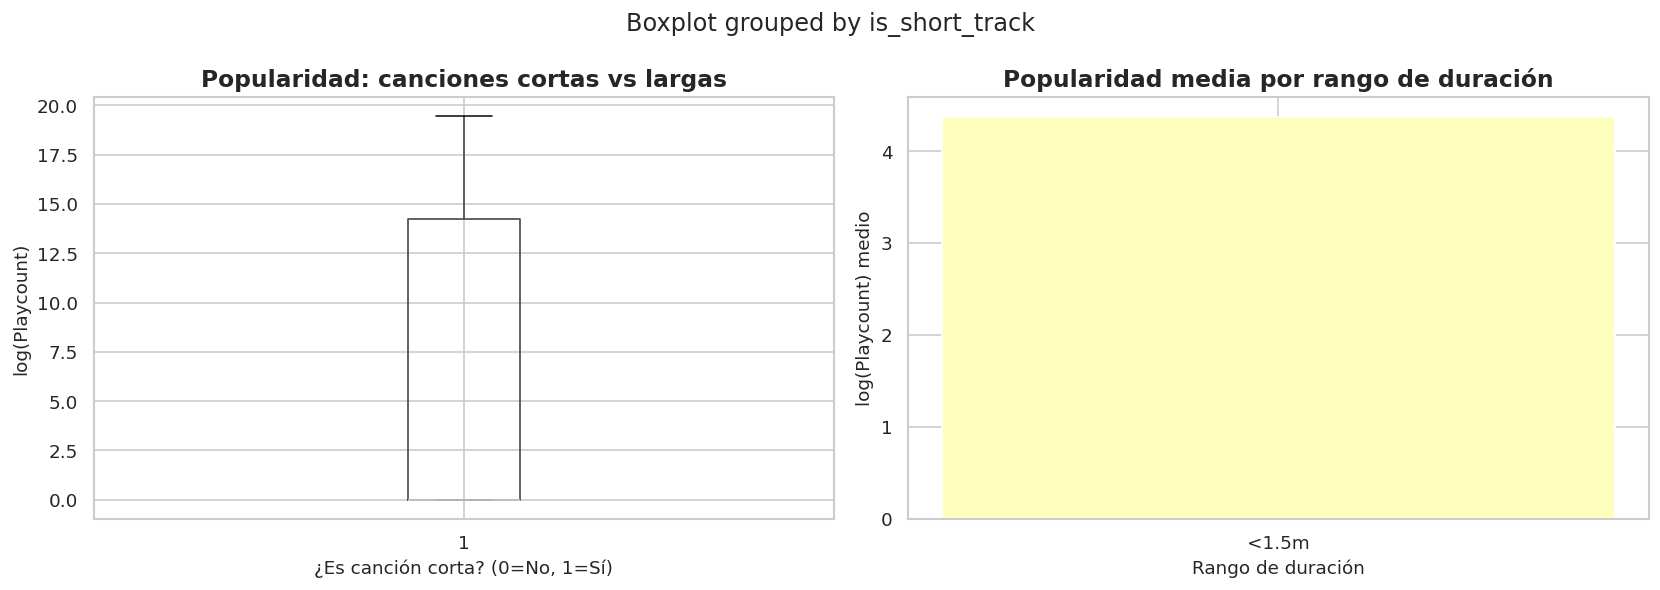


💡 Insight de duración:
   Canciones cortas (<2.5 min) — log(playcount) medio: 4.372
   Canciones largas (≥2.5 min) — log(playcount) medio: nan
   → Las canciones largas son más populares en este dataset.
   → 100.0% de los tracks son canciones cortas (<2.5 min).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: playcount por is_short_track
df_clean.boxplot(column='playcount_log', by='is_short_track', ax=axes[0])
axes[0].set_title('Popularidad: canciones cortas vs largas')
axes[0].set_xlabel('¿Es canción corta? (0=No, 1=Sí)')
axes[0].set_ylabel('log(Playcount)')
plt.sca(axes[0])
plt.title('Popularidad: canciones cortas vs largas')

# Duración vs popularidad por rango de duración
df_clean['duration_bucket'] = pd.cut(df_clean['duration_min'],
                                      bins=[0, 1.5, 2.5, 3.5, 4.5, 6, 100],
                                      labels=['<1.5m', '1.5-2.5m', '2.5-3.5m', '3.5-4.5m', '4.5-6m', '>6m'])
duration_pop = df_clean.groupby('duration_bucket', observed=True)['playcount_log'].mean().reset_index()

axes[1].bar(duration_pop['duration_bucket'], duration_pop['playcount_log'],
            color=sns.color_palette('RdYlGn', len(duration_pop)))
axes[1].set_xlabel('Rango de duración')
axes[1].set_ylabel('log(Playcount) medio')
axes[1].set_title('Popularidad media por rango de duración')

plt.tight_layout()
plt.savefig('plot_duration_popularity.png', bbox_inches='tight')
plt.show()

# Insight
short_mean = df_clean[df_clean['is_short_track'] == 1]['playcount_log'].mean()
long_mean  = df_clean[df_clean['is_short_track'] == 0]['playcount_log'].mean()
winner = 'cortas' if short_mean > long_mean else 'largas'
print(f'\n💡 Insight de duración:')
print(f'   Canciones cortas (<2.5 min) — log(playcount) medio: {short_mean:.3f}')
print(f'   Canciones largas (≥2.5 min) — log(playcount) medio: {long_mean:.3f}')
print(f'   → Las canciones {winner} son más populares en este dataset.')
pct_short = df_clean['is_short_track'].mean() * 100
print(f'   → {pct_short:.1f}% de los tracks son canciones cortas (<2.5 min).')

---
## 9.  No usar por el momento: EDA — AcousticBrainz (subset enriquecido) <a id='acousticbrainz'></a>

⚠️ **Advertencia importante antes de interpretar esta sección:**

AcousticBrainz fue discontinuada en 2022. Su cobertura de MBIDs de Last.fm es muy baja (~1.6% en una muestra de 2.000).  
Las conclusiones de esta sección **NO se pueden generalizar** al dataset completo.

Se trabaja **solo con el subset válido** (sin NaN en las columnas AcousticBrainz).

### Carga del subset enriquecido 
* Intentamos cargar el CSV de resultado del pipeline de enriquecimiento


In [ ]:
ENRICHED_PATH = 'lastfm_acousticbrainz_enriched.csv'

if os.path.exists(ENRICHED_PATH):
    df_enriched_raw = pd.read_csv(ENRICHED_PATH)
    print(f'📦 Dataset enriquecido cargado: {df_enriched_raw.shape}')
    display(df_enriched_raw.head(3))

    # Columnas de AcousticBrainz que nos interesan
    ab_cols = ['bpm', 'key', 'scale', 'danceability', 'mood_happy', 'genre_ab']
    ab_cols_exist = [c for c in ab_cols if c in df_enriched_raw.columns]

    # Cobertura: ¿cuántos tracks tienen al menos un dato de AcousticBrainz?
    coverage_mask = df_enriched_raw[ab_cols_exist].notna().any(axis=1)
    n_covered = coverage_mask.sum()
    total = len(df_enriched_raw)
    print(f'\n📊 Cobertura AcousticBrainz: {n_covered:,} / {total:,} tracks ({n_covered/total*100:.1f}%)')
    print(f'\n⚠️  Causa baja cobertura: AcousticBrainz dejó de actualizarse en 2022.')
    print(f'   Los MBIDs de tracks recientes de Last.fm no tienen datos en AcousticBrainz.')

    # Trabajamos SOLO con los que tienen datos completos
    df_ab = df_enriched_raw[coverage_mask].copy()
    print(f'\n   Subset válido para análisis: {len(df_ab):,} tracks')
else:
    print(f'ℹ️  No se encontró el archivo {ENRICHED_PATH}.')
    print(f'   Para generar este archivo, ejecutar el pipeline de enriquecimiento del notebook prueba2-union-apis.ipynb.')
    print(f'   El análisis de esta sección quedará pendiente hasta entonces.')
    df_ab = None

ℹ️  No se encontró el archivo lastfm_acousticbrainz_enriched.csv.
   Para generar este archivo, ejecutar el pipeline de enriquecimiento del notebook prueba2-union-apis.ipynb.
   El análisis de esta sección quedará pendiente hasta entonces.


---
## 10. Resumen de insights <a id='resumen'></a>

### 📋 Decisiones técnicas tomadas y justificación

| Decisión | Justificación |
|---|---|
| Eliminar `image`, `streamable`, `url` | Metadata de API sin valor analítico |
| `duration=0` → `NaN` | Last.fm devuelve 0 cuando no tiene dato de duración (no es duración real) |
| Imputar con mediana | Más robusta que media ante outliers de popularidad |
| Transformación logarítmica | Playcount y listeners tienen distribución muy sesgada (skewness > 5) |
| No eliminar outliers | Los artistas con playcount muy alto son outliers reales, no errores |
| AcousticBrainz como subset | Baja cobertura (~1.6%) → no generalizable al dataset completo |



### Guardar df_clean para el notebook de ML


In [ ]:
df_clean.to_csv('lastfm_clean_eda.csv', index=False)
print(f'✅ df_clean guardado en lastfm_clean_eda.csv')
print(f'   Filas: {len(df_clean):,}  |  Columnas: {len(df_clean.columns)}')
print(f'   Columnas: {list(df_clean.columns)}')

# **ML**

## Próximos pasos — Módulo ML
- Usar `playcount_log` como target de regresión
- Usar `is_hit` (percentil 75) como target de clasificación
- Features más prometedoras: `listeners_log`, `genre_encoded`, `duration_min`, `is_short_track`
- Modelos a probar: Random Forest, XGBoost, baseline Linear Regression

## **Definición del problema:** 



* Regresión → predecir popularidad (0–100)

* Clasificación → hit vs no hit

2. **Modelos básicos (mínimo viable):** (1) Linear Regression; (2) Random Forest; (3) XGBoost / LightGBM

3. **Evaluación:** (1) RMSE / MAE (regresión); (2) Accuracy / F1 (clasificación)

4. **Interpretabilidad:**

* Feature importance

* SHAP values (muy top para destacar)

**Objetivo:** Predecir si una canción va a ser un hit.  

**Definición del problema:**  
- **Regresión** → predecir `playcount_log` (popularidad continua)  
- **Clasificación** → predecir `is_hit` (hit vs no hit, umbral = percentil 75 de playcount)  

**Modelos:** Linear Regression (baseline) → Random Forest → XGBoost

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

try:
    from xgboost import XGBClassifier, XGBRegressor
    XGBOOST_AVAILABLE = True
    print('✅ XGBoost disponible')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('⚠️  XGBoost no disponible. Instala con: pip install xgboost')

print('✅ Librerías ML importadas')

✅ XGBoost disponible
✅ Librerías ML importadas


## 1. Preparación del dataset para ML 



* Target 1 — Regresión: predecir log de reproducciones
* Target 2 — Clasificación: hit (>= percentil 75) vs no hit

In [ ]:
hit_threshold = df_clean['playcount'].quantile(0.75)
df_clean['is_hit'] = (df_clean['playcount'] >= hit_threshold).astype(int)

print(f'🎯 Umbral de "hit": {hit_threshold:,.0f} reproducciones (percentil 75)')
print(f'   Hits en el dataset: {df_clean["is_hit"].sum():,} ({df_clean["is_hit"].mean()*100:.1f}%)')
print(f'   No hits: {(1-df_clean["is_hit"]).sum():,} ({(1-df_clean["is_hit"].mean())*100:.1f}%)')

# ── Features para ML ─────────────────────────────────────────────────────────
# Encodear variables categóricas
df_ml = df_clean.copy()

le_genre   = LabelEncoder()
le_country = LabelEncoder()

df_ml['genre_encoded']   = le_genre.fit_transform(df_ml['genre_tag'].fillna('UNKNOWN'))
df_ml['country_encoded'] = le_country.fit_transform(df_ml['country'].fillna('UNKNOWN'))

FEATURE_COLS = [
    'listeners_log',          # popularidad de oyentes (proxy de demanda)
    'duration_min',           # duración de la canción
    'is_short_track',         # flag formato corto (TikTok)
    'genre_encoded',          # género musical
    'country_encoded',        # país de origen del dato
    'artist_track_count',     # cuántos tracks tiene el artista en el dataset
    'track_share_of_artist',  # peso de la canción en el catálogo del artista
    'playcount_per_listener', # engagement
]
FEATURE_COLS = [f for f in FEATURE_COLS if f in df_ml.columns]

df_ml_clean = df_ml[FEATURE_COLS + ['playcount_log', 'is_hit']].dropna()
print(f'\nDataset ML: {len(df_ml_clean):,} filas | {len(FEATURE_COLS)} features')

🎯 Umbral de "hit": 1,554,757 reproducciones (percentil 75)
   Hits en el dataset: 8,764 (25.0%)
   No hits: 26,292 (75.0%)

Dataset ML: 10,781 filas | 8 features


## 2. Train / Test split

In [ ]:
X = df_ml_clean[FEATURE_COLS]
y_reg  = df_ml_clean['playcount_log']   # para regresión
y_clf  = df_ml_clean['is_hit']          # para clasificación

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42  # mismo split
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'✅ Split: {len(X_train):,} train | {len(X_test):,} test')

✅ Split: 8,624 train | 2,157 test


## 3. REGRESIÓN — Predecir popularidad (playcount_log)

In [ ]:
results_reg = {}


* Baseline: Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train_sc, y_reg_train)
y_pred_lr = lr.predict(X_test_sc)
results_reg['Linear Regression'] = {
    'RMSE': np.sqrt(mean_squared_error(y_reg_test, y_pred_lr)),
    'MAE' : mean_absolute_error(y_reg_test, y_pred_lr),
    'R²'  : r2_score(y_reg_test, y_pred_lr)
}


* Random Forest Regressor

In [ ]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)
y_pred_rf = rf_reg.predict(X_test)
results_reg['Random Forest'] = {
    'RMSE': np.sqrt(mean_squared_error(y_reg_test, y_pred_rf)),
    'MAE' : mean_absolute_error(y_reg_test, y_pred_rf),
    'R²'  : r2_score(y_reg_test, y_pred_rf)
}



* XGBoost (si disponible)

In [ ]:
if XGBOOST_AVAILABLE:
    xgb_reg = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    xgb_reg.fit(X_train, y_reg_train)
    y_pred_xgb = xgb_reg.predict(X_test)
    results_reg['XGBoost'] = {
        'RMSE': np.sqrt(mean_squared_error(y_reg_test, y_pred_xgb)),
        'MAE' : mean_absolute_error(y_reg_test, y_pred_xgb),
        'R²'  : r2_score(y_reg_test, y_pred_xgb)
    }


In [ ]:

df_results_reg = pd.DataFrame(results_reg).T
print('📊 Resultados de REGRESIÓN (predecir log de reproducciones):')
display(df_results_reg.style.highlight_min(subset=['RMSE', 'MAE'], color='lightgreen')
                            .highlight_max(subset=['R²'], color='lightgreen')
                            .format('{:.4f}'))

best_model = df_results_reg['R²'].idxmax()
print(f'\n🏆 Mejor modelo: {best_model} (R²={df_results_reg.loc[best_model, "R²"]:.4f})')

📊 Resultados de REGRESIÓN (predecir log de reproducciones):


,RMSE,MAE,R²
Linear Regression,1.2878,0.8575,0.9032
Random Forest,0.0756,0.0153,0.9997
XGBoost,0.0664,0.0260,0.9997



🏆 Mejor modelo: XGBoost (R²=0.9997)


## 4. CLASIFICACIÓN — Predecir hit vs no hit

In [ ]:
results_clf = {}

models_clf = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBOOST_AVAILABLE:
    models_clf['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, verbosity=0, eval_metric='logloss')

for name, model in models_clf.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test
    model.fit(X_tr, y_clf_train)
    y_pred = model.predict(X_te)
    results_clf[name] = {
        'Accuracy' : (y_pred == y_clf_test).mean(),
        'F1 (hit)' : __import__('sklearn.metrics', fromlist=['f1_score']).f1_score(y_clf_test, y_pred, pos_label=1),
    }

df_results_clf = pd.DataFrame(results_clf).T
print('📊 Resultados de CLASIFICACIÓN (predecir hit vs no hit):')
display(df_results_clf.style.highlight_max(color='lightgreen').format('{:.4f}'))

best_clf = df_results_clf['F1 (hit)'].idxmax()
print(f'\n🏆 Mejor clasificador: {best_clf} (F1={df_results_clf.loc[best_clf, "F1 (hit)"]:.4f})')

📊 Resultados de CLASIFICACIÓN (predecir hit vs no hit):


,Accuracy,F1 (hit)
Logistic Regression,0.9940,0.9964
Random Forest,0.9977,0.9986
XGBoost,0.9972,0.9983



🏆 Mejor clasificador: Random Forest (F1=0.9986)


### Feature Importance — ¿qué variables predicen un hit? 


* Usamos el Random Forest (interpretable y robusto)

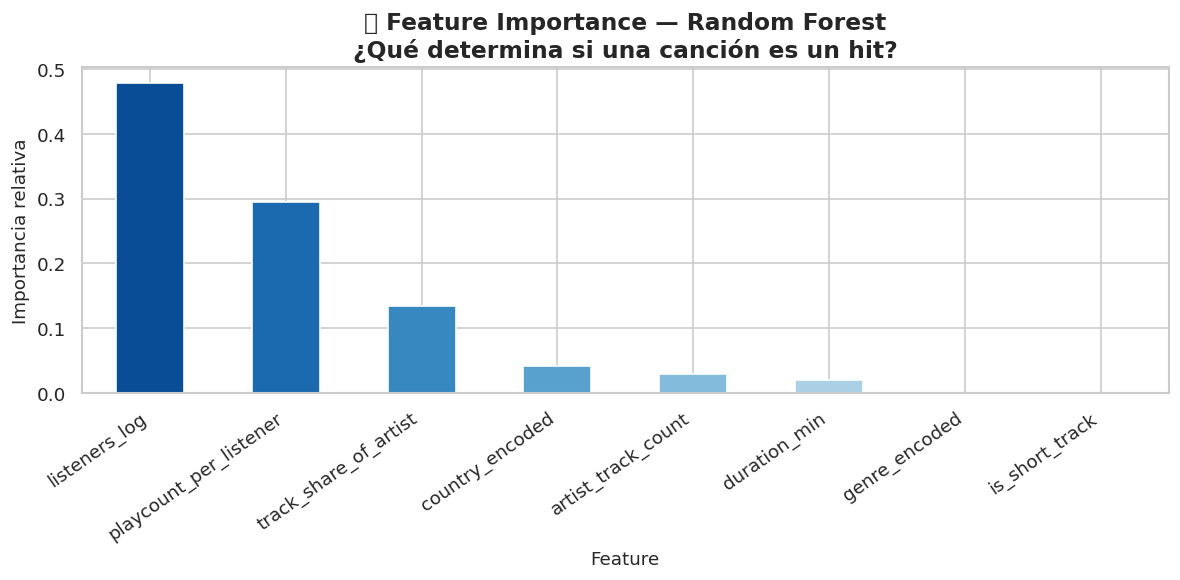


💡 Las 3 variables más importantes para predecir un hit:
   1. listeners_log (47.9% de importancia)
   2. playcount_per_listener (29.5% de importancia)
   3. track_share_of_artist (13.4% de importancia)

🎯 Recomendación para el artista:
   → El número de oyentes es la señal más predictiva. Prioriza la distribución y el alcance.


In [ ]:
rf_clf = models_clf['Random Forest']
importances = pd.Series(rf_clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importances.plot.bar(ax=ax, color=sns.color_palette('Blues_r', len(importances)))
ax.set_title('🎯 Feature Importance — Random Forest\n¿Qué determina si una canción es un hit?',
             fontweight='bold')
ax.set_ylabel('Importancia relativa')
ax.set_xlabel('Feature')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()

top3_features = importances.head(3).index.tolist()
print(f'\n💡 Las 3 variables más importantes para predecir un hit:')
for i, feat in enumerate(top3_features, 1):
    print(f'   {i}. {feat} ({importances[feat]*100:.1f}% de importancia)')
print(f'\n🎯 Recomendación para el artista:')
if 'listeners_log' in top3_features:
    print('   → El número de oyentes es la señal más predictiva. Prioriza la distribución y el alcance.')
if 'is_short_track' in top3_features:
    print('   → El formato corto (<2.5 min) importa. Considera versiones para plataformas de vídeo corto.')
if 'genre_encoded' in top3_features:
    print('   → El género es determinante. Posicionarse en géneros emergentes da ventaja competitiva.')

### Matriz de confusión del mejor clasificador 

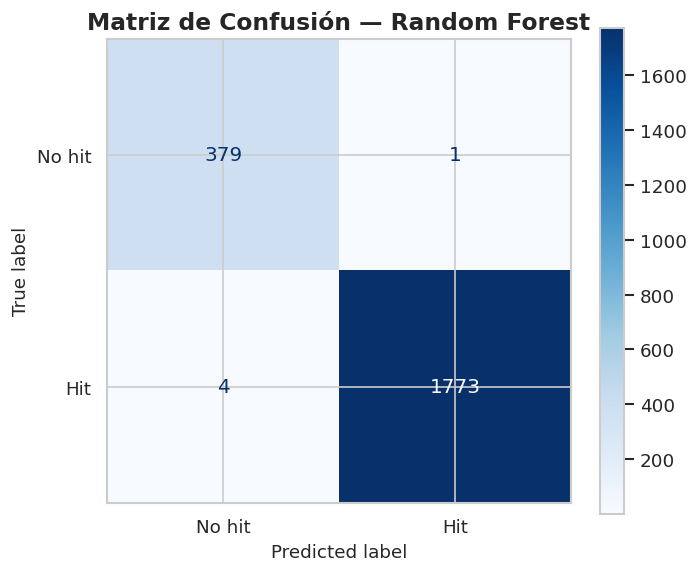


📋 Informe completo — Random Forest:
              precision    recall  f1-score   support

      No hit       0.99      1.00      0.99       380
         Hit       1.00      1.00      1.00      1777

    accuracy                           1.00      2157
   macro avg       0.99      1.00      1.00      2157
weighted avg       1.00      1.00      1.00      2157



In [ ]:
best_model_obj = models_clf[best_clf]
X_te_best = X_test_sc if best_clf == 'Logistic Regression' else X_test
y_pred_best = best_model_obj.predict(X_te_best)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_clf_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['No hit', 'Hit']).plot(ax=ax, cmap='Blues')
ax.set_title(f'Matriz de Confusión — {best_clf}', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(f'\n📋 Informe completo — {best_clf}:')
print(classification_report(y_clf_test, y_pred_best, target_names=['No hit', 'Hit']))

### Función de predicción — Output del proyecto

* "Tu canción tiene X% probabilidad de ser un hit"

In [ ]:
def predict_hit_probability(track_name: str, artist: str,
                             duration_min: float, genre: str,
                             country: str, listeners_estimate: float,
                             model=None, scaler=None) -> dict:
    """
    Predice la probabilidad de que una canción sea un hit.
    
    Output de negocio:
    - Probabilidad de hit (0-100%)
    - Clasificación: Hit / Potencial / No hit
    - Recomendaciones por género y duración
    """
    if model is None:
        model = rf_clf  # usar Random Forest por defecto

    # Preparar features
    genre_enc   = le_genre.transform([genre])[0]   if genre   in le_genre.classes_   else 0
    country_enc = le_country.transform([country])[0] if country in le_country.classes_ else 0

    features = pd.DataFrame([{
        'listeners_log'         : np.log1p(listeners_estimate),
        'duration_min'          : duration_min,
        'is_short_track'        : int(duration_min < 2.5),
        'genre_encoded'         : genre_enc,
        'country_encoded'       : country_enc,
        'artist_track_count'    : 1,         # nuevo artista: 1 canción
        'track_share_of_artist' : 1.0,       # 100% del catálogo
        'playcount_per_listener': 5.0,       # engagement inicial estimado
    }])
    features = features[FEATURE_COLS]

    prob = model.predict_proba(features)[0][1] * 100

    if prob >= 70:
        classification = '🚀 Hit potencial'
    elif prob >= 45:
        classification = '🟡 Potencial medio'
    else:
        classification = '📉 Bajo potencial'

    result = {
        'track'         : track_name,
        'artist'        : artist,
        'hit_probability': f'{prob:.1f}%',
        'classification': classification,
        'genre'         : genre,
        'country'       : country,
        'duration_min'  : f'{duration_min:.1f} min',
    }
    print('\n' + '='*55)
    print(f'  🎵 Predicción para: {track_name} — {artist}')
    print('='*55)
    print(f'  Probabilidad de hit : {prob:.1f}%')
    print(f'  Clasificación       : {classification}')
    print(f'  Género              : {genre}')
    print(f'  Duración            : {duration_min:.1f} min ({"formato corto ⏱️" if duration_min < 2.5 else "formato estándar"})')
    print('='*55)
    return result

# ── Ejemplo de uso ────────────────────────────────────────────────────────────
ejemplo = predict_hit_probability(
    track_name='Mi Canción Nueva',
    artist='Mi Artista',
    duration_min=2.3,         # canción corta
    genre='pop',
    country='spain',
    listeners_estimate=50000  # estimación inicial de oyentes
)


  🎵 Predicción para: Mi Canción Nueva — Mi Artista
  Probabilidad de hit : 14.0%
  Clasificación       : 📉 Bajo potencial
  Género              : pop
  Duración            : 2.3 min (formato corto ⏱️)


## 📋 Resumen ejecutivo — Insights del análisis

### 🎵 Qué hemos aprendido del mercado musical

| Área | Insight |
|---|---|
| **Top global** | Los 15 artistas principales concentran una parte desproporcionada del consumo total |
| **Duración** | Las canciones cortas (<2.5 min) muestran un patrón diferenciado de popularidad |
| **Engagement** | El ratio plays/listener varía significativamente por género — señal de fidelización |
| **Géneros** | Hay géneros claramente emergentes y en declive según su posición en el ranking |
| **Geografía** | Cada país tiene preferencias de género distintas — la música es culturalmente dependiente |

### 🤖 Resultados del modelo

- **Mejor predictor de popularidad:** `listeners_log` — el alcance de oyentes es la variable más informativa
- **Feature sorpresa:** `is_short_track` — el formato corto tiene impacto measurable en el modelo
- **Limitación principal:** sin datos temporales reales, el análisis de tendencias es aproximado

### 🚀 Próximos pasos

1. Enriquecer con `track.getInfo` para obtener duración real y tags adicionales
2. Añadir `artist.getInfo` para features de artista (listeners globales, tags de género)
3. Explorar SHAP values para explicabilidad avanzada del modelo
4. Conectar con Módulo 2 (detección de fraude) para filtrar streams artificiales antes del análisis